In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/__results__.html
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/final_waste_research_metadata_v1.0.zip
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/__notebook__.ipynb
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/__output__.json
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/custom.css
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset_Split/metadata/test_bangladesh.csv
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset_Split/metadata/validation.csv
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset_Split/metadata/test_international.csv
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset_Split/metadata/train.csv
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset_Split/metadata/test.csv
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset

In [2]:
# ============================================================
# DENSENET121 RESEARCH PIPELINE
# STEP 00 — IMPORTS
# ============================================================

import os
import gc
import json
import random
import shutil
import time
import math
import warnings

from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
from torchvision.models import (
    densenet121,
    DenseNet121_Weights
)

from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score,
    precision_score,
    recall_score
)

warnings.filterwarnings("ignore")

print("=" * 80)
print("DENSENET121 RESEARCH PIPELINE")
print("=" * 80)

print("PyTorch     :", torch.__version__)
print("TorchVision :", torchvision.__version__)

DENSENET121 RESEARCH PIPELINE
PyTorch     : 2.10.0+cu128
TorchVision : 0.25.0+cu128


In [3]:
# ============================================================
# STEP 01 — TRAINING ENVIRONMENT
# ============================================================

print("=" * 80)
print("TRAINING ENVIRONMENT")
print("=" * 80)

print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())

if torch.cuda.is_available():

    print("GPU             :", torch.cuda.get_device_name(0))

    gpu_memory = (
        torch.cuda.get_device_properties(0).total_memory
        / (1024 ** 3)
    )

    print(
        f"GPU Memory      : {gpu_memory:.2f} GB"
    )

    DEVICE = torch.device("cuda")

else:

    print("⚠️ CUDA GPU NOT AVAILABLE")

    DEVICE = torch.device("cpu")

print("\nUsing device:", DEVICE)

TRAINING ENVIRONMENT
PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4
GPU Memory      : 14.56 GB

Using device: cuda


In [4]:
# ============================================================
# STEP 02 — REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("✓ Random seed:", SEED)

✓ Random seed: 42


In [5]:
# ============================================================
# STEP 03 — PATH DISCOVERY
# ============================================================

KAGGLE_INPUT = Path("/kaggle/input")
KAGGLE_WORKING = Path("/kaggle/working")

print("=" * 80)
print("SEARCHING FOR FINAL DATASET")
print("=" * 80)

metadata_candidates = list(
    KAGGLE_INPUT.rglob("Final_Waste_Dataset/research_metadata")
)

if not metadata_candidates:

    metadata_candidates = list(
        KAGGLE_INPUT.rglob("research_metadata")
    )

print("\nMetadata candidates:")

for p in metadata_candidates:
    print("→", p)

if not metadata_candidates:

    raise FileNotFoundError(
        "Final_Waste_Dataset/research_metadata not found."
    )

META = metadata_candidates[0]

print("\nSelected META:")
print(META)

SEARCHING FOR FINAL DATASET

Metadata candidates:
→ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata

Selected META:
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata


In [6]:
# ============================================================
# STEP 04 — IMAGE ROOT DISCOVERY
# ============================================================

possible_image_roots = []

for root in [
    KAGGLE_INPUT,
    KAGGLE_WORKING
]:

    if root.exists():

        for p in root.rglob("images"):

            if not p.is_dir():
                continue

            try:

                classes_found = {
                    x.name
                    for x in p.iterdir()
                    if x.is_dir()
                }

            except Exception:

                continue

            required = {
                "Cardboard",
                "Glass",
                "Metal",
                "Paper",
                "Plastic"
            }

            if required.issubset(classes_found):

                possible_image_roots.append(p)

print("=" * 80)
print("IMAGE ROOT CANDIDATES")
print("=" * 80)

for p in possible_image_roots:

    print("→", p)

if not possible_image_roots:

    raise FileNotFoundError(
        "Could not find image root containing all 5 classes."
    )

IMAGE_ROOT = possible_image_roots[0]

print("\nIMAGE_ROOT:")
print(IMAGE_ROOT)

IMAGE ROOT CANDIDATES
→ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/images

IMAGE_ROOT:
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/images


In [7]:
# ============================================================
# STEP 05 — METADATA PATHS
# ============================================================

FINAL_METADATA = META / "final_metadata.csv"
TRAIN_METADATA = META / "train_final.csv"
VAL_METADATA = META / "validation_final.csv"
TEST_METADATA = META / "test_final.csv"

BD_TEST_METADATA = META / "test_bangladesh_final.csv"
INTL_TEST_METADATA = META / "test_international_final.csv"

required_files = [
    FINAL_METADATA,
    TRAIN_METADATA,
    VAL_METADATA,
    TEST_METADATA,
    BD_TEST_METADATA,
    INTL_TEST_METADATA
]

print("=" * 80)
print("METADATA FILE CHECK")
print("=" * 80)

for p in required_files:

    if p.exists():

        print("✓", p)

    else:

        print("✗", p)
        raise FileNotFoundError(p)

METADATA FILE CHECK
✓ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/final_metadata.csv
✓ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/train_final.csv
✓ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/validation_final.csv
✓ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/test_final.csv
✓ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/test_bangladesh_final.csv
✓ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/test_international_final.csv


In [8]:
# ============================================================
# STEP 06 — LOAD METADATA
# ============================================================

final_df = pd.read_csv(FINAL_METADATA)
train_df = pd.read_csv(TRAIN_METADATA)
val_df = pd.read_csv(VAL_METADATA)
test_df = pd.read_csv(TEST_METADATA)

bd_test_original = pd.read_csv(BD_TEST_METADATA)
intl_test_original = pd.read_csv(INTL_TEST_METADATA)

print("=" * 80)
print("DATASET LOADED")
print("=" * 80)

print("Final       :", len(final_df))
print("Train       :", len(train_df))
print("Validation  :", len(val_df))
print("Test        :", len(test_df))
print("BD CSV      :", len(bd_test_original))
print("Intl CSV    :", len(intl_test_original))

DATASET LOADED
Final       : 10668
Train       : 7245
Validation  : 1552
Test        : 1871
BD CSV      : 319
Intl CSV    : 1289


In [9]:
# ============================================================
# STEP 07 — METADATA COLUMN AUDIT
# ============================================================

print("=" * 80)
print("METADATA COLUMN AUDIT")
print("=" * 80)

datasets = {
    "final": final_df,
    "train": train_df,
    "validation": val_df,
    "test": test_df,
    "bangladesh_original": bd_test_original,
    "international_original": intl_test_original
}

required_columns = [
    "filename",
    "class",
    "source",
    "country",
    "dataset_group",
    "original_path"
]

for name, df in datasets.items():

    print(f"\n{name.upper()}")

    print(df.columns.tolist())

    missing_columns = [
        c for c in required_columns
        if c not in df.columns
    ]

    if missing_columns:

        raise ValueError(
            f"{name} missing columns: {missing_columns}"
        )

print("\n✓ Metadata schema valid")

METADATA COLUMN AUDIT

FINAL
['filename', 'class', 'source', 'country', 'dataset_group', 'original_path']

TRAIN
['filename', 'class', 'source', 'country', 'dataset_group', 'original_path']

VALIDATION
['filename', 'class', 'source', 'country', 'dataset_group', 'original_path']

TEST
['filename', 'class', 'source', 'country', 'dataset_group', 'original_path']

BANGLADESH_ORIGINAL
['filename', 'class', 'source', 'country', 'dataset_group', 'original_path']

INTERNATIONAL_ORIGINAL
['filename', 'class', 'source', 'country', 'dataset_group', 'original_path']

✓ Metadata schema valid


In [10]:
# ============================================================
# STEP 08 — DATASET SPLIT AUDIT
# ============================================================

print("=" * 80)
print("DATASET COUNT AUDIT")
print("=" * 80)

print(f"Final metadata : {len(final_df):,}")
print(f"Train          : {len(train_df):,}")
print(f"Validation     : {len(val_df):,}")
print(f"Test           : {len(test_df):,}")

split_total = (
    len(train_df)
    + len(val_df)
    + len(test_df)
)

print("\nTrain + Validation + Test:", split_total)

if split_total != len(final_df):

    raise ValueError(
        "Dataset split mismatch. STOP."
    )

print("\n✓ Split totals match")

DATASET COUNT AUDIT
Final metadata : 10,668
Train          : 7,245
Validation     : 1,552
Test           : 1,871

Train + Validation + Test: 10668

✓ Split totals match


In [11]:
# ============================================================
# STEP 09 — RECONSTRUCT COMPLETE TEST GROUPS
# ============================================================

print("=" * 80)
print("RECONSTRUCTING COMPLETE TEST GROUPS")
print("=" * 80)

test_work = test_df.copy()

# ------------------------------------------------------------
# Normalize text fields
# ------------------------------------------------------------

for col in [
    "filename",
    "source",
    "country",
    "dataset_group"
]:

    test_work[col] = (
        test_work[col]
        .fillna("")
        .astype(str)
        .str.strip()
    )

# ------------------------------------------------------------
# Normalize filename
# ------------------------------------------------------------

test_work["filename_key"] = (
    test_work["filename"]
    .str.strip()
    .str.lower()
)

# ------------------------------------------------------------
# Build groups DIRECTLY from final test metadata
# ------------------------------------------------------------

bd_test_df = test_work[
    (
        test_work["source"].str.lower() == "bangladesh"
    )
    |
    (
        test_work["country"].str.lower() == "bangladesh"
    )
    |
    (
        test_work["dataset_group"].str.lower() == "bangladesh"
    )
].copy()

international_test_df = test_work[
    ~test_work["filename_key"].isin(
        set(bd_test_df["filename_key"])
    )
].copy()

# ------------------------------------------------------------
# Remove helper column later
# ------------------------------------------------------------

print("Overall test       :", len(test_work))
print("Bangladesh test    :", len(bd_test_df))
print("International test :", len(international_test_df))

print(
    "\nBD + International :",
    len(bd_test_df) + len(international_test_df)
)

if (
    len(bd_test_df)
    + len(international_test_df)
    != len(test_work)
):

    raise ValueError(
        "Test group reconstruction failed."
    )

print("\n✓ Complete test group coverage restored")

RECONSTRUCTING COMPLETE TEST GROUPS
Overall test       : 1871
Bangladesh test    : 582
International test : 1289

BD + International : 1871

✓ Complete test group coverage restored


In [12]:
# ============================================================
# STEP 09 — RECONSTRUCT COMPLETE TEST GROUPS
# ============================================================

print("=" * 80)
print("RECONSTRUCTING COMPLETE TEST GROUPS")
print("=" * 80)

test_work = test_df.copy()

# ------------------------------------------------------------
# Normalize text fields
# ------------------------------------------------------------

for col in [
    "filename",
    "source",
    "country",
    "dataset_group"
]:

    test_work[col] = (
        test_work[col]
        .fillna("")
        .astype(str)
        .str.strip()
    )

# ------------------------------------------------------------
# Normalize filename
# ------------------------------------------------------------

test_work["filename_key"] = (
    test_work["filename"]
    .str.strip()
    .str.lower()
)

# ------------------------------------------------------------
# Build groups DIRECTLY from final test metadata
# ------------------------------------------------------------

bd_test_df = test_work[
    (
        test_work["source"].str.lower() == "bangladesh"
    )
    |
    (
        test_work["country"].str.lower() == "bangladesh"
    )
    |
    (
        test_work["dataset_group"].str.lower() == "bangladesh"
    )
].copy()

international_test_df = test_work[
    ~test_work["filename_key"].isin(
        set(bd_test_df["filename_key"])
    )
].copy()

# ------------------------------------------------------------
# Remove helper column later
# ------------------------------------------------------------

print("Overall test       :", len(test_work))
print("Bangladesh test    :", len(bd_test_df))
print("International test :", len(international_test_df))

print(
    "\nBD + International :",
    len(bd_test_df) + len(international_test_df)
)

if (
    len(bd_test_df)
    + len(international_test_df)
    != len(test_work)
):

    raise ValueError(
        "Test group reconstruction failed."
    )

print("\n✓ Complete test group coverage restored")

RECONSTRUCTING COMPLETE TEST GROUPS
Overall test       : 1871
Bangladesh test    : 582
International test : 1289

BD + International : 1871

✓ Complete test group coverage restored


In [13]:
# ============================================================
# STEP 11 — CLASS CONFIGURATION
# ============================================================

CLASS_NAMES = [
    "Cardboard",
    "Glass",
    "Metal",
    "Paper",
    "Plastic"
]

CLASS_TO_IDX = {
    cls: idx
    for idx, cls in enumerate(CLASS_NAMES)
}

IDX_TO_CLASS = {
    idx: cls
    for cls, idx in CLASS_TO_IDX.items()
}

print("=" * 80)
print("CLASS MAPPING")
print("=" * 80)

for cls, idx in CLASS_TO_IDX.items():

    print(f"{cls:<12} : {idx}")

CLASS MAPPING
Cardboard    : 0
Glass        : 1
Metal        : 2
Paper        : 3
Plastic      : 4


In [14]:
# ============================================================
# STEP 12 — CLASS AUDIT
# ============================================================

print("=" * 80)
print("CLASS AUDIT")
print("=" * 80)

for name, df in {
    "train": train_df,
    "validation": val_df,
    "test": test_df
}.items():

    classes = sorted(
        df["class"].dropna().unique().tolist()
    )

    print(f"\n{name}:")
    print(classes)

    if set(classes) != set(CLASS_NAMES):

        raise ValueError(
            f"{name} does not contain all 5 classes."
        )

print("\n✓ All 5 classes present")

CLASS AUDIT

train:
['Cardboard', 'Glass', 'Metal', 'Paper', 'Plastic']

validation:
['Cardboard', 'Glass', 'Metal', 'Paper', 'Plastic']

test:
['Cardboard', 'Glass', 'Metal', 'Paper', 'Plastic']

✓ All 5 classes present


In [15]:
# ============================================================
# RESTORE FINAL RESEARCH METADATA
# ============================================================

from pathlib import Path
import pandas as pd

# ------------------------------------------------------------
# CORRECT KAGGLE INPUT PATH
# ------------------------------------------------------------

META = Path(
    "/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata"
)

print("=" * 80)
print("RESTORING FINAL RESEARCH METADATA")
print("=" * 80)

print("Metadata directory:")
print(META)

# ------------------------------------------------------------
# CHECK DIRECTORY
# ------------------------------------------------------------

if not META.exists():
    raise FileNotFoundError(
        f"Metadata directory not found:\n{META}"
    )

print("\n✓ Metadata directory found")

print("\nAvailable files:")

for f in sorted(META.iterdir()):
    print(" -", f.name)

# ------------------------------------------------------------
# LOAD METADATA
# ------------------------------------------------------------

final_df = pd.read_csv(
    META / "final_metadata.csv"
)

train_df = pd.read_csv(
    META / "train_final.csv"
)

val_df = pd.read_csv(
    META / "validation_final.csv"
)

test_df = pd.read_csv(
    META / "test_final.csv"
)

bd_test = pd.read_csv(
    META / "test_bangladesh_final.csv"
)

international_test_df = pd.read_csv(
    META / "test_international_final.csv"
)

# ------------------------------------------------------------
# RESTORE SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("DATASET RESTORED SUCCESSFULLY")
print("=" * 80)

print(
    f"Final metadata       : {len(final_df):,}"
)

print(
    f"Train                : {len(train_df):,}"
)

print(
    f"Validation           : {len(val_df):,}"
)

print(
    f"Overall Test         : {len(test_df):,}"
)

print(
    f"Bangladesh Test      : {len(bd_test):,}"
)

print(
    f"International Test   : {len(international_test_df):,}"
)

# ------------------------------------------------------------
# CONSISTENCY CHECK
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("CONSISTENCY CHECK")
print("-" * 80)

split_total = (
    len(train_df)
    + len(val_df)
    + len(test_df)
)

print(
    f"Train + Validation + Test : {split_total:,}"
)

print(
    f"Final metadata            : {len(final_df):,}"
)

print(
    "MATCH                     :",
    split_total == len(final_df)
)

# ------------------------------------------------------------
# BASIC DATA CHECK
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("CLASS DISTRIBUTION — TRAIN")
print("-" * 80)

print(
    train_df["class"]
    .value_counts()
    .sort_index()
)

print("\n" + "-" * 80)
print("SOURCE DISTRIBUTION — TRAIN")
print("-" * 80)

print(
    train_df["source"]
    .value_counts()
)

print("\n✓ METADATA RESTORATION COMPLETE")

RESTORING FINAL RESEARCH METADATA
Metadata directory:
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata

✓ Metadata directory found

Available files:
 - FINAL_CHECKPOINT.json
 - final_metadata.csv
 - manual_review_decisions.csv
 - test_bangladesh_final.csv
 - test_final.csv
 - test_international_final.csv
 - train_final.csv
 - training_class_balance.csv
 - validation_final.csv

DATASET RESTORED SUCCESSFULLY
Final metadata       : 10,668
Train                : 7,245
Validation           : 1,552
Overall Test         : 1,871
Bangladesh Test      : 319
International Test   : 1,289

--------------------------------------------------------------------------------
CONSISTENCY CHECK
--------------------------------------------------------------------------------
Train + Validation + Test : 10,668
Final metadata            : 10,668
MATCH                     : True

--------------------------------------------------------------------------------
CLASS

In [16]:
# ============================================================
# STEP 13 — TRAINING CLASS DISTRIBUTION
# ============================================================

train_class_counts = (
    train_df["class"]
    .value_counts()
    .reindex(CLASS_NAMES)
)

print("=" * 80)
print("TRAINING CLASS DISTRIBUTION")
print("=" * 80)

print(train_class_counts)

max_count = train_class_counts.max()
min_count = train_class_counts.min()

imbalance_ratio = max_count / min_count

print("\nMaximum:", max_count)
print("Minimum:", min_count)
print(
    f"Imbalance ratio: {imbalance_ratio:.4f}"
)

TRAINING CLASS DISTRIBUTION
class
Cardboard    1193
Glass        1433
Metal        1594
Paper        1793
Plastic      1232
Name: count, dtype: int64

Maximum: 1793
Minimum: 1193
Imbalance ratio: 1.5029


In [17]:
# ============================================================
# STEP 14 — CLASS WEIGHTS
# ============================================================

class_counts = train_class_counts.values.astype(np.float64)

total_train = class_counts.sum()
num_classes = len(CLASS_NAMES)

class_weights = (
    total_train
    / (num_classes * class_counts)
)

class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE
)

print("=" * 80)
print("CLASS WEIGHTS")
print("=" * 80)

for cls, weight in zip(
    CLASS_NAMES,
    class_weights
):

    print(
        f"{cls:<12}: {weight:.4f}"
    )

CLASS WEIGHTS
Cardboard   : 1.2146
Glass       : 1.0112
Metal       : 0.9090
Paper       : 0.8081
Plastic     : 1.1761


In [18]:
# ============================================================
# STEP 15 — IMAGE PATH RESOLUTION
# ============================================================

print("=" * 80)
print("IMAGE PATH RESOLUTION")
print("=" * 80)

def resolve_image_path(filename, class_name):

    filename = str(filename)

    # Primary path
    p = IMAGE_ROOT / class_name / filename

    if p.exists():
        return p

    # Case-insensitive fallback
    class_dir = IMAGE_ROOT / class_name

    if class_dir.exists():

        target = filename.lower()

        for candidate in class_dir.iterdir():

            if candidate.name.lower() == target:

                return candidate

    return None


# Test resolution
sample_rows = train_df.head(20)

missing_samples = []

for _, row in sample_rows.iterrows():

    path = resolve_image_path(
        row["filename"],
        row["class"]
    )

    if path is None:

        missing_samples.append(
            row["filename"]
        )

print(
    "Missing in first 20:",
    len(missing_samples)
)

if missing_samples:

    print(missing_samples)

    raise FileNotFoundError(
        "Image path resolution failed."
    )

print("\n✓ Image paths resolve correctly")

IMAGE PATH RESOLUTION
Missing in first 20: 0

✓ Image paths resolve correctly


In [19]:
# ============================================================
# STEP 16 — IMAGE EXISTENCE AUDIT
# ============================================================

def audit_image_paths(df, name):

    missing = []

    for _, row in df.iterrows():

        path = resolve_image_path(
            row["filename"],
            row["class"]
        )

        if path is None:

            missing.append(
                row["filename"]
            )

    print(
        f"{name:<15}: "
        f"{len(df):,} images | "
        f"missing = {len(missing):,}"
    )

    return missing


print("=" * 80)
print("FULL IMAGE EXISTENCE AUDIT")
print("=" * 80)

train_missing = audit_image_paths(
    train_df,
    "Train"
)

val_missing = audit_image_paths(
    val_df,
    "Validation"
)

test_missing = audit_image_paths(
    test_df,
    "Test"
)

if (
    train_missing
    or val_missing
    or test_missing
):

    raise FileNotFoundError(
        "Some final dataset images are missing."
    )

print("\n✓ All images found")

FULL IMAGE EXISTENCE AUDIT
Train          : 7,245 images | missing = 0
Validation     : 1,552 images | missing = 0
Test           : 1,871 images | missing = 0

✓ All images found


In [20]:
# ============================================================
# STEP 17 — PYTORCH DATASET
# ============================================================

class WasteDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_root,
        transform=None
    ):

        self.df = dataframe.reset_index(drop=True)
        self.image_root = Path(image_root)
        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, index):

        row = self.df.iloc[index]

        filename = row["filename"]
        class_name = row["class"]

        image_path = resolve_image_path(
            filename,
            class_name
        )

        if image_path is None:

            raise FileNotFoundError(
                f"Image not found: "
                f"{filename}"
            )

        try:

            image = Image.open(
                image_path
            ).convert("RGB")

        except Exception as e:

            raise RuntimeError(
                f"Could not open image: "
                f"{image_path}"
            ) from e

        label = CLASS_TO_IDX[
            class_name
        ]

        if self.transform:

            image = self.transform(image)

        return image, label

In [21]:
# ============================================================
# STEP 18 — IMAGE TRANSFORMS
# ============================================================

IMG_SIZE = 224

weights = DenseNet121_Weights.DEFAULT

imagenet_mean = [
    0.485,
    0.456,
    0.406
]

imagenet_std = [
    0.229,
    0.224,
    0.225
]

train_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=10
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15,
        hue=0.02
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])


eval_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])

print("✓ Transforms ready")
print("Image size:", IMG_SIZE)

✓ Transforms ready
Image size: 224


In [22]:
# ============================================================
# STEP 19 — CREATE DATASETS
# ============================================================

train_dataset = WasteDataset(
    train_df,
    IMAGE_ROOT,
    train_transform
)

valid_dataset = WasteDataset(
    val_df,
    IMAGE_ROOT,
    eval_transform
)

test_dataset = WasteDataset(
    test_df,
    IMAGE_ROOT,
    eval_transform
)

bd_test_dataset = WasteDataset(
    bd_test_df,
    IMAGE_ROOT,
    eval_transform
)

intl_test_dataset = WasteDataset(
    international_test_df,
    IMAGE_ROOT,
    eval_transform
)

print("=" * 80)
print("DATASETS CREATED")
print("=" * 80)

print("Train       :", len(train_dataset))
print("Validation  :", len(valid_dataset))
print("Test        :", len(test_dataset))
print("Bangladesh  :", len(bd_test_dataset))
print("International:", len(intl_test_dataset))

DATASETS CREATED
Train       : 7245
Validation  : 1552
Test        : 1871
Bangladesh  : 582
International: 1289


In [23]:
# ============================================================
# STEP 20 — DATALOADERS
# ============================================================

BATCH_SIZE = 32
NUM_WORKERS = 2

PIN_MEMORY = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

bd_test_loader = DataLoader(
    bd_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

intl_test_loader = DataLoader(
    intl_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

print("=" * 80)
print("DATALOADERS")
print("=" * 80)

print("Train batches :", len(train_loader))
print("Valid batches :", len(valid_loader))
print("Test batches  :", len(test_loader))
print("BD batches    :", len(bd_test_loader))
print("Intl batches  :", len(intl_test_loader))

DATALOADERS
Train batches : 227
Valid batches : 49
Test batches  : 59
BD batches    : 19
Intl batches  : 41


In [24]:
# ============================================================
# STEP 21 — GPU BATCH TEST
# ============================================================

images, labels = next(
    iter(train_loader)
)

print("=" * 80)
print("BATCH TEST")
print("=" * 80)

print("CPU images :", images.shape)
print("CPU labels :", labels.shape)

images = images.to(
    DEVICE,
    non_blocking=True
)

labels = labels.to(
    DEVICE,
    non_blocking=True
)

print("\nDevice test:")
print("Images:", images.device)
print("Labels:", labels.device)

assert images.shape == (
    BATCH_SIZE,
    3,
    IMG_SIZE,
    IMG_SIZE
)

print("\n✓ Batch test successful")

BATCH TEST
CPU images : torch.Size([32, 3, 224, 224])
CPU labels : torch.Size([32])

Device test:
Images: cuda:0
Labels: cuda:0

✓ Batch test successful


In [25]:
# ============================================================
# STEP 22 — DENSENET121 MODEL
# ============================================================

print("=" * 80)
print("CREATING DENSENET121")
print("=" * 80)

model = densenet121(
    weights=DenseNet121_Weights.DEFAULT
)

# Replace classifier
in_features = model.classifier.in_features

model.classifier = nn.Linear(
    in_features,
    len(CLASS_NAMES)
)

model = model.to(DEVICE)

print(model.classifier)

print("\n✓ DenseNet121 ready")

CREATING DENSENET121
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 168MB/s]


Linear(in_features=1024, out_features=5, bias=True)

✓ DenseNet121 ready


In [26]:
# ============================================================
# STEP 25A — DENSENET121 CLEAN ANALYSIS ENVIRONMENT
# ============================================================

import os
import json
import time
import copy
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms
from PIL import Image

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

CLASS_NAMES = [
    "Cardboard",
    "Glass",
    "Metal",
    "Paper",
    "Plastic"
]

CLASS_TO_IDX = {
    name: i
    for i, name in enumerate(CLASS_NAMES)
}

NUM_CLASSES = 5

print("=" * 80)
print("DENSENET121 — CLEAN ENVIRONMENT")
print("=" * 80)

print("PyTorch :", torch.__version__)
print("Device  :", DEVICE)

if torch.cuda.is_available():
    print("GPU     :", torch.cuda.get_device_name(0))

print("Classes :", CLASS_NAMES)

DENSENET121 — CLEAN ENVIRONMENT
PyTorch : 2.10.0+cu128
Device  : cuda
GPU     : Tesla T4
Classes : ['Cardboard', 'Glass', 'Metal', 'Paper', 'Plastic']


In [27]:
# ============================================================
# STEP 26 — AUTHORITATIVE DATASET PATH
# ============================================================

BASE = Path(
    "/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code"
)

FINAL_ROOT = BASE / "Final_Waste_Dataset"

IMAGE_ROOT = FINAL_ROOT / "images"
META = FINAL_ROOT / "research_metadata"

print("=" * 80)
print("AUTHORITATIVE DATASET PATH")
print("=" * 80)

print("BASE       :", BASE)
print("FINAL_ROOT :", FINAL_ROOT)
print("IMAGE_ROOT :", IMAGE_ROOT)
print("META       :", META)

assert FINAL_ROOT.exists(), FINAL_ROOT
assert IMAGE_ROOT.exists(), IMAGE_ROOT
assert META.exists(), META

print("\n✓ Dataset root exists")
print("✓ Image root exists")
print("✓ Metadata root exists")

AUTHORITATIVE DATASET PATH
BASE       : /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code
FINAL_ROOT : /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset
IMAGE_ROOT : /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/images
META       : /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata

✓ Dataset root exists
✓ Image root exists
✓ Metadata root exists


In [28]:
# ============================================================
# STEP 27 — LOAD FINAL RESEARCH METADATA
# ============================================================

FINAL_METADATA = META / "final_metadata.csv"
TRAIN_METADATA = META / "train_final.csv"
VAL_METADATA = META / "validation_final.csv"
TEST_METADATA = META / "test_final.csv"

BD_METADATA = META / "test_bangladesh_final.csv"
INTL_METADATA = META / "test_international_final.csv"

files = {
    "final": FINAL_METADATA,
    "train": TRAIN_METADATA,
    "validation": VAL_METADATA,
    "test": TEST_METADATA,
    "bangladesh": BD_METADATA,
    "international": INTL_METADATA
}

for name, path in files.items():
    print(
        f"{'✓' if path.exists() else '✗'} "
        f"{name:<15} {path}"
    )

    if not path.exists():
        raise FileNotFoundError(path)

final_df = pd.read_csv(FINAL_METADATA)
train_df = pd.read_csv(TRAIN_METADATA)
val_df = pd.read_csv(VAL_METADATA)
test_df = pd.read_csv(TEST_METADATA)

bd_test_df = pd.read_csv(BD_METADATA)
intl_test_df = pd.read_csv(INTL_METADATA)

print("\nDATASET COUNTS")

print("Final        :", len(final_df))
print("Train        :", len(train_df))
print("Validation   :", len(val_df))
print("Test         :", len(test_df))
print("Bangladesh   :", len(bd_test_df))
print("International:", len(intl_test_df))

✓ final           /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/final_metadata.csv
✓ train           /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/train_final.csv
✓ validation      /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/validation_final.csv
✓ test            /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/test_final.csv
✓ bangladesh      /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/test_bangladesh_final.csv
✓ international   /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/test_international_final.csv

DATASET COUNTS
Final        : 10668
Train        : 7245
Validation   : 1552
Test         : 1871
Bangladesh   : 319
International: 1289


In [29]:
# ============================================================
# STEP 28 — DATASET INTEGRITY CHECK
# ============================================================

print("=" * 80)
print("DATASET INTEGRITY CHECK")
print("=" * 80)

assert len(final_df) == 10668

assert (
    len(train_df)
    + len(val_df)
    + len(test_df)
) == 10668

print("✓ Total dataset        :", len(final_df))
print("✓ Train + Val + Test   :", 
      len(train_df) + len(val_df) + len(test_df))

train_paths = set(train_df["original_path"])
val_paths = set(val_df["original_path"])
test_paths = set(test_df["original_path"])

print("\nLEAKAGE")

print(
    "Train ∩ Validation:",
    len(train_paths & val_paths)
)

print(
    "Train ∩ Test      :",
    len(train_paths & test_paths)
)

print(
    "Validation ∩ Test:",
    len(val_paths & test_paths)
)

assert len(train_paths & val_paths) == 0
assert len(train_paths & test_paths) == 0
assert len(val_paths & test_paths) == 0

print("\n✓ NO SPLIT LEAKAGE")
print("✓ DATASET FROZEN")

DATASET INTEGRITY CHECK
✓ Total dataset        : 10668
✓ Train + Val + Test   : 10668

LEAKAGE
Train ∩ Validation: 0
Train ∩ Test      : 0
Validation ∩ Test: 0

✓ NO SPLIT LEAKAGE
✓ DATASET FROZEN


In [30]:
# ============================================================
# STEP 29 — RECONSTRUCT COMPLETE TEST GROUPS
# ============================================================

print("=" * 80)
print("RECONSTRUCTING COMPLETE TEST GROUPS")
print("=" * 80)

required_group_columns = [
    "filename",
    "class",
    "source",
    "country",
    "dataset_group",
    "original_path"
]

for col in required_group_columns:
    assert col in test_df.columns

# Normalize text
test_work = test_df.copy()

for col in [
    "filename",
    "class",
    "source",
    "country",
    "dataset_group"
]:
    test_work[col] = (
        test_work[col]
        .astype(str)
        .str.strip()
    )

# Bangladesh
bd_complete_test = test_work[
    (
        test_work["source"].str.lower()
        == "bangladesh"
    )
    |
    (
        test_work["country"].str.lower()
        == "bangladesh"
    )
    |
    (
        test_work["dataset_group"].str.lower()
        == "bangladesh"
    )
].copy()

# International
intl_complete_test = test_work[
    ~test_work.index.isin(
        bd_complete_test.index
    )
].copy()

print("Overall test       :", len(test_work))
print("Bangladesh test    :", len(bd_complete_test))
print("International test :", len(intl_complete_test))
print(
    "BD + International :",
    len(bd_complete_test)
    + len(intl_complete_test)
)

assert (
    len(bd_complete_test)
    + len(intl_complete_test)
) == len(test_work)

print("\n✓ COMPLETE TEST GROUP COVERAGE")

RECONSTRUCTING COMPLETE TEST GROUPS
Overall test       : 1871
Bangladesh test    : 582
International test : 1289
BD + International : 1871

✓ COMPLETE TEST GROUP COVERAGE


In [31]:
# ============================================================
# STEP 30 — DATASET CLASS
# ============================================================

class WasteMetadataDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_root,
        transform=None
    ):

        self.df = dataframe.reset_index(drop=True)
        self.image_root = Path(image_root)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def resolve_image_path(self, row):

        filename = str(row["filename"])

        # Direct class directory
        class_name = str(row["class"])

        candidates = [
            self.image_root / class_name / filename,
            self.image_root / filename
        ]

        for path in candidates:

            if path.exists():
                return path

        # Recursive fallback
        matches = list(
            self.image_root.rglob(filename)
        )

        if matches:
            return matches[0]

        raise FileNotFoundError(
            f"Image not found: {filename}"
        )

    def __getitem__(self, index):

        row = self.df.iloc[index]

        image_path = self.resolve_image_path(row)

        image = Image.open(
            image_path
        ).convert("RGB")

        label = CLASS_TO_IDX[
            row["class"]
        ]

        if self.transform:
            image = self.transform(image)

        return image, label

In [32]:
# ============================================================
# STEP 31 — TEST TRANSFORM
# ============================================================

TEST_TRANSFORM = transforms.Compose([

    transforms.Resize(
        (224, 224)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])

print("✓ Test transform ready")

✓ Test transform ready


In [33]:
# ============================================================
# STEP 32 — TEST DATALOADER
# ============================================================

test_dataset = WasteMetadataDataset(
    test_work,
    IMAGE_ROOT,
    TEST_TRANSFORM
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("=" * 80)
print("TEST DATALOADER")
print("=" * 80)

print("Samples :", len(test_dataset))
print("Batches :", len(test_loader))

TEST DATALOADER
Samples : 1871
Batches : 59


In [34]:
# ============================================================
# STEP 33 — IMAGE LOADING TEST
# ============================================================

images, labels = next(
    iter(test_loader)
)

print("Images :", images.shape)
print("Labels :", labels.shape)

print("Device :", DEVICE)

images = images.to(DEVICE)
labels = labels.to(DEVICE)

print("Images device:", images.device)
print("Labels device:", labels.device)

assert images.shape[1:] == (
    3, 224, 224
)

print("\n✓ IMAGE PIPELINE WORKING")

Images : torch.Size([32, 3, 224, 224])
Labels : torch.Size([32])
Device : cuda
Images device: cuda:0
Labels device: cuda:0

✓ IMAGE PIPELINE WORKING


In [35]:
# ============================================================
# STEP 34 — ROBUST DENSENET121 CHECKPOINT SEARCH
# ============================================================

SEARCH_ROOTS = [
    Path("/kaggle/input"),
    Path("/kaggle/working")
]

patterns = [
    "*.pth",
    "*.pt",
    "*.ckpt",
    "*.bin"
]

checkpoint_candidates = []

for root in SEARCH_ROOTS:

    if not root.exists():
        continue

    for pattern in patterns:

        for p in root.rglob(pattern):

            checkpoint_candidates.append(p)

# Remove duplicates
checkpoint_candidates = sorted(
    set(checkpoint_candidates)
)

print("=" * 80)
print("ALL CHECKPOINT CANDIDATES")
print("=" * 80)

for p in checkpoint_candidates:

    size_mb = (
        p.stat().st_size
        / (1024 ** 2)
    )

    print(
        f"{size_mb:8.2f} MB | {p}"
    )

print(
    "\nTotal:",
    len(checkpoint_candidates)
)

ALL CHECKPOINT CANDIDATES
  269.58 MB | /kaggle/input/notebooks/kbmhkhan/model-training-setup-1st-model-run/waste_model_results/checkpoints/resnet50_best.pth
   90.02 MB | /kaggle/input/notebooks/kbmhkhan/model-training-setup-1st-model-run/waste_model_results/resnet50_experiments/E2_strong_augmentation/resnet50_best.pth
   90.02 MB | /kaggle/input/notebooks/kbmhkhan/model-training-setup-1st-model-run/waste_model_results/resnet50_experiments/E3_adamw_cosine/resnet50_best.pth
   90.02 MB | /kaggle/input/notebooks/kbmhkhan/model-training-setup-1st-model-run/waste_model_results/resnet50_experiments/E4_label_smoothing/resnet50_best.pth
   90.02 MB | /kaggle/input/notebooks/kbmhkhan/model-training-setup-1st-model-run/waste_model_results/resnet50_experiments/E5_high_resolution/resnet50_best.pth

Total: 5


In [36]:
# ============================================================
# STEP 35 — IDENTIFY DENSENET CHECKPOINT
# ============================================================

dense_candidates = []

for p in checkpoint_candidates:

    name = p.name.lower()

    if any(
        keyword in name
        for keyword in [
            "dense",
            "densenet",
            "dn121"
        ]
    ):

        dense_candidates.append(p)

print("=" * 80)
print("DENSENET121 CANDIDATES")
print("=" * 80)

for i, p in enumerate(
    dense_candidates,
    start=1
):

    size_mb = (
        p.stat().st_size
        / (1024 ** 2)
    )

    print(
        f"[{i}] {size_mb:.2f} MB"
    )

    print(p)

print(
    "\nTotal:",
    len(dense_candidates)
)

DENSENET121 CANDIDATES

Total: 0


In [37]:
# ============================================================
# STEP 36 — DENSENET121 MODEL
# ============================================================

def create_densenet121(
    num_classes=5,
    pretrained=False
):

    if pretrained:

        weights = (
            models.DenseNet121_Weights.DEFAULT
        )

    else:

        weights = None

    model = models.densenet121(
        weights=weights
    )

    in_features = (
        model.classifier.in_features
    )

    model.classifier = nn.Linear(
        in_features,
        num_classes
    )

    return model

In [38]:
# ============================================================
# STEP 37 — CREATE DENSENET121
# ============================================================

MODEL = create_densenet121(
    num_classes=NUM_CLASSES,
    pretrained=False
)

MODEL = MODEL.to(DEVICE)

print("=" * 80)
print("DENSENET121 MODEL")
print("=" * 80)

print(MODEL.classifier)
print("\nDevice:", DEVICE)

DENSENET121 MODEL
Linear(in_features=1024, out_features=5, bias=True)

Device: cuda


In [39]:
# ============================================================
# STEP 36 — DENSENET121 RESEARCH CONFIGURATION
# ============================================================

import os
import json
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# DEVICE
# ------------------------------------------------------------

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# ------------------------------------------------------------
# REPRODUCIBILITY
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ------------------------------------------------------------
# DATASET CONFIG
# ------------------------------------------------------------

CLASS_NAMES = [
    "Cardboard",
    "Glass",
    "Metal",
    "Paper",
    "Plastic"
]

CLASS_TO_IDX = {
    "Cardboard": 0,
    "Glass": 1,
    "Metal": 2,
    "Paper": 3,
    "Plastic": 4
}

NUM_CLASSES = len(CLASS_NAMES)

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

# ------------------------------------------------------------
# TRAINING CONFIG
# ------------------------------------------------------------

NUM_EPOCHS = 20

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 1e-4

# ------------------------------------------------------------
# OUTPUT DIRECTORIES
# ------------------------------------------------------------

RESULTS_DIR = Path(
    "/kaggle/working/densenet121_results"
)

CHECKPOINT_DIR = RESULTS_DIR / "checkpoints"
CURVE_DIR = RESULTS_DIR / "training_curves"
REPORT_DIR = RESULTS_DIR / "classification_reports"
CM_DIR = RESULTS_DIR / "confusion_matrices"
ERROR_DIR = RESULTS_DIR / "error_analysis"

for directory in [
    RESULTS_DIR,
    CHECKPOINT_DIR,
    CURVE_DIR,
    REPORT_DIR,
    CM_DIR,
    ERROR_DIR
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )

BEST_CHECKPOINT = (
    CHECKPOINT_DIR /
    "densenet121_best.pth"
)

LAST_CHECKPOINT = (
    CHECKPOINT_DIR /
    "densenet121_last.pth"
)

HISTORY_PATH = (
    RESULTS_DIR /
    "densenet121_training_history.csv"
)

print("=" * 80)
print("DENSENET121 RESEARCH CONFIGURATION")
print("=" * 80)

print("Device       :", DEVICE)
print("Classes      :", CLASS_NAMES)
print("Num classes  :", NUM_CLASSES)
print("Image size   :", IMG_SIZE)
print("Batch size   :", BATCH_SIZE)
print("Epochs       :", NUM_EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Weight decay :", WEIGHT_DECAY)
print("Seed         :", SEED)

if torch.cuda.is_available():

    print(
        "GPU          :",
        torch.cuda.get_device_name(0)
    )

    print(
        "GPU memory   :",
        round(
            torch.cuda.get_device_properties(0)
            .total_memory / 1024**3,
            2
        ),
        "GB"
    )

print("\nOutput:")
print(RESULTS_DIR)

DENSENET121 RESEARCH CONFIGURATION
Device       : cuda
Classes      : ['Cardboard', 'Glass', 'Metal', 'Paper', 'Plastic']
Num classes  : 5
Image size   : 224
Batch size   : 32
Epochs       : 20
Learning rate: 0.0001
Weight decay : 0.0001
Seed         : 42
GPU          : Tesla T4
GPU memory   : 14.56 GB

Output:
/kaggle/working/densenet121_results


In [40]:
# ============================================================
# STEP 37 — VERIFY DATASET / DATALOADER STATE
# ============================================================

required_variables = [
    "train_df",
    "val_df",
    "test_df",
    "train_loader",
    "valid_loader",
    "test_loader"
]

print("=" * 80)
print("VERIFYING DATASET STATE")
print("=" * 80)

missing = []

for variable in required_variables:

    if variable in globals():

        print("✓", variable)

    else:

        print("✗", variable)
        missing.append(variable)

if missing:

    raise RuntimeError(
        "Missing variables: " +
        ", ".join(missing)
    )

print("\nDataset sizes:")
print("Train      :", len(train_df))
print("Validation :", len(val_df))
print("Test       :", len(test_df))

print("\nDataLoader:")
print("Train batches:", len(train_loader))
print("Valid batches:", len(valid_loader))
print("Test batches :", len(test_loader))

print("\n✓ Dataset state ready")

VERIFYING DATASET STATE
✓ train_df
✓ val_df
✓ test_df
✓ train_loader
✓ valid_loader
✓ test_loader

Dataset sizes:
Train      : 7245
Validation : 1552
Test       : 1871

DataLoader:
Train batches: 227
Valid batches: 49
Test batches : 59

✓ Dataset state ready


In [41]:
# ============================================================
# STEP 38 — GPU BATCH TEST
# ============================================================

images, labels = next(
    iter(train_loader)
)

print("=" * 80)
print("GPU BATCH TEST")
print("=" * 80)

print("CPU images :", images.shape)
print("CPU labels :", labels.shape)

images = images.to(
    DEVICE,
    non_blocking=True
)

labels = labels.to(
    DEVICE,
    non_blocking=True
)

print("\nDevice images:", images.device)
print("Device labels:", labels.device)

assert images.ndim == 4
assert images.shape[1] == 3
assert images.shape[2] == 224
assert images.shape[3] == 224

print("\n✓ Input shape verified")
print("✓ GPU batch transfer successful")

GPU BATCH TEST
CPU images : torch.Size([32, 3, 224, 224])
CPU labels : torch.Size([32])

Device images: cuda:0
Device labels: cuda:0

✓ Input shape verified
✓ GPU batch transfer successful


In [42]:
# ============================================================
# STEP 39 — CLASS BALANCE / WEIGHTS
# ============================================================

train_counts = (
    train_df["class"]
    .value_counts()
    .reindex(CLASS_NAMES)
)

print("=" * 80)
print("DENSENET121 TRAINING CLASS BALANCE")
print("=" * 80)

print(train_counts)

max_count = train_counts.max()
min_count = train_counts.min()

imbalance_ratio = (
    max_count / min_count
)

print("\nMaximum:", max_count)
print("Minimum:", min_count)

print(
    f"Imbalance ratio: {imbalance_ratio:.4f}"
)

# ------------------------------------------------------------
# Balanced inverse-frequency weights
# ------------------------------------------------------------

class_weights = (
    len(train_df) /
    (
        NUM_CLASSES *
        train_counts.values
    )
)

class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE
)

print("\nClass weights:")

for cls, weight in zip(
    CLASS_NAMES,
    class_weights
):

    print(
        f"{cls:<12}: {weight:.4f}"
    )

print(
    "\nNOTE:"
)

print(
    "Baseline DenseNet121 will use "
    "standard CrossEntropyLoss."
)

print(
    "Class-weighted loss will be a "
    "separate research experiment."
)

DENSENET121 TRAINING CLASS BALANCE
class
Cardboard    1193
Glass        1433
Metal        1594
Paper        1793
Plastic      1232
Name: count, dtype: int64

Maximum: 1793
Minimum: 1193
Imbalance ratio: 1.5029

Class weights:
Cardboard   : 1.2146
Glass       : 1.0112
Metal       : 0.9090
Paper       : 0.8081
Plastic     : 1.1761

NOTE:
Baseline DenseNet121 will use standard CrossEntropyLoss.
Class-weighted loss will be a separate research experiment.


In [43]:
# ============================================================
# STEP 40 — CREATE DENSENET121
# ============================================================

def create_densenet121(
    num_classes=5,
    pretrained=True
):

    if pretrained:

        weights = (
            models.DenseNet121_Weights.DEFAULT
        )

    else:

        weights = None

    model = models.densenet121(
        weights=weights
    )

    in_features = (
        model.classifier.in_features
    )

    model.classifier = nn.Linear(
        in_features,
        num_classes
    )

    return model


MODEL = create_densenet121(
    num_classes=NUM_CLASSES,
    pretrained=True
)

MODEL = MODEL.to(DEVICE)

print("=" * 80)
print("DENSENET121 MODEL CREATED")
print("=" * 80)

print(
    "Classifier:",
    MODEL.classifier
)

print(
    "Device:",
    next(MODEL.parameters()).device
)

DENSENET121 MODEL CREATED
Classifier: Linear(in_features=1024, out_features=5, bias=True)
Device: cuda:0


In [44]:
# ============================================================
# STEP 41 — MODEL PARAMETER ANALYSIS
# ============================================================

total_params = sum(
    p.numel()
    for p in MODEL.parameters()
)

trainable_params = sum(
    p.numel()
    for p in MODEL.parameters()
    if p.requires_grad
)

print("=" * 80)
print("DENSENET121 PARAMETER ANALYSIS")
print("=" * 80)

print(
    f"Total parameters    : {total_params:,}"
)

print(
    f"Trainable parameters: {trainable_params:,}"
)

print(
    f"Model size approx   : "
    f"{total_params * 4 / (1024**2):.2f} MB"
)

DENSENET121 PARAMETER ANALYSIS
Total parameters    : 6,958,981
Trainable parameters: 6,958,981
Model size approx   : 26.55 MB


In [45]:
# ============================================================
# STEP 42 — LOSS / OPTIMIZER / SCHEDULER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    MODEL.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS
)

print("=" * 80)
print("TRAINING COMPONENTS")
print("=" * 80)

print("Loss      : CrossEntropyLoss")
print("Optimizer : AdamW")
print("LR        :", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)
print("Scheduler : CosineAnnealingLR")
print("Epochs    :", NUM_EPOCHS)

print("\n✓ Ready")

TRAINING COMPONENTS
Loss      : CrossEntropyLoss
Optimizer : AdamW
LR        : 0.0001
Weight decay: 0.0001
Scheduler : CosineAnnealingLR
Epochs    : 20

✓ Ready


In [46]:
# ============================================================
# STEP 23 — MODEL PARAMETERS
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("=" * 80)
print("DENSENET121 PARAMETERS")
print("=" * 80)

print(
    f"Total parameters     : {total_params:,}"
)

print(
    f"Trainable parameters : {trainable_params:,}"
)

DENSENET121 PARAMETERS
Total parameters     : 6,958,981
Trainable parameters : 6,958,981


In [47]:
# ============================================================
# STEP 42 — LOSS / OPTIMIZER / SCHEDULER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    MODEL.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS
)

print("=" * 80)
print("TRAINING COMPONENTS")
print("=" * 80)

print("Loss      : CrossEntropyLoss")
print("Optimizer : AdamW")
print("LR        :", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)
print("Scheduler : CosineAnnealingLR")
print("Epochs    :", NUM_EPOCHS)

print("\n✓ Ready")

TRAINING COMPONENTS
Loss      : CrossEntropyLoss
Optimizer : AdamW
LR        : 0.0001
Weight decay: 0.0001
Scheduler : CosineAnnealingLR
Epochs    : 20

✓ Ready


In [48]:
# ============================================================
# STEP 43 — DENSENET121 FORWARD PASS TEST
# ============================================================

MODEL.eval()

with torch.no_grad():

    sample_images, sample_labels = next(
        iter(test_loader)
    )

    sample_images = sample_images.to(
        DEVICE
    )

    sample_outputs = MODEL(
        sample_images
    )

print("=" * 80)
print("DENSENET121 FORWARD PASS")
print("=" * 80)

print("Input :", sample_images.shape)
print("Output:", sample_outputs.shape)

assert sample_outputs.shape[1] == NUM_CLASSES

print("\n✓ Forward pass successful")
print("✓ Output classes:", sample_outputs.shape[1])

DENSENET121 FORWARD PASS
Input : torch.Size([32, 3, 224, 224])
Output: torch.Size([32, 5])

✓ Forward pass successful
✓ Output classes: 5


In [49]:
# ============================================================
# STEP 24 — LOSS + OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

print("✓ Loss      : Weighted CrossEntropyLoss")
print("✓ Optimizer : AdamW")
print("✓ LR        : 1e-4")
print("✓ Scheduler : ReduceLROnPlateau")

✓ Loss      : Weighted CrossEntropyLoss
✓ Optimizer : AdamW
✓ LR        : 1e-4
✓ Scheduler : ReduceLROnPlateau


In [50]:
# ============================================================
# STEP 44 — TRAINING / VALIDATION FUNCTIONS
# ============================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() *
            images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = (
        running_loss / total
    )

    epoch_accuracy = (
        correct / total
    )

    return epoch_loss, epoch_accuracy


@torch.no_grad()
def validate_one_epoch(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        running_loss += (
            loss.item() *
            images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = (
        running_loss / total
    )

    epoch_accuracy = (
        correct / total
    )

    return epoch_loss, epoch_accuracy


print("✓ Training functions ready")

✓ Training functions ready


In [51]:
# ============================================================
# STEP 25 — RESEARCH OUTPUT DIRECTORIES
# ============================================================

OUTPUT_ROOT = (
    KAGGLE_WORKING
    / "DenseNet121_Research_Results"
)

DIRS = {

    "root": OUTPUT_ROOT,

    "checkpoint": OUTPUT_ROOT / "checkpoint",

    "metrics": OUTPUT_ROOT / "metrics",

    "confusion": OUTPUT_ROOT / "confusion_matrices",

    "plots": OUTPUT_ROOT / "plots",

    "errors": OUTPUT_ROOT / "errors",

    "gallery": OUTPUT_ROOT / "misclassified_gallery",

    "logs": OUTPUT_ROOT / "logs"
}

for path in DIRS.values():

    path.mkdir(
        parents=True,
        exist_ok=True
    )

print("=" * 80)
print("OUTPUT DIRECTORIES")
print("=" * 80)

for name, path in DIRS.items():

    print(
        f"{name:<15}: {path}"
    )

OUTPUT DIRECTORIES
root           : /kaggle/working/DenseNet121_Research_Results
checkpoint     : /kaggle/working/DenseNet121_Research_Results/checkpoint
metrics        : /kaggle/working/DenseNet121_Research_Results/metrics
confusion      : /kaggle/working/DenseNet121_Research_Results/confusion_matrices
plots          : /kaggle/working/DenseNet121_Research_Results/plots
errors         : /kaggle/working/DenseNet121_Research_Results/errors
gallery        : /kaggle/working/DenseNet121_Research_Results/misclassified_gallery
logs           : /kaggle/working/DenseNet121_Research_Results/logs


In [52]:
# ============================================================
# STEP 26 — TRAINING FUNCTIONS
# ============================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item()
            * images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = (
        running_loss / total
    )

    epoch_accuracy = (
        correct / total
    )

    return epoch_loss, epoch_accuracy


@torch.no_grad()
def evaluate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        running_loss += (
            loss.item()
            * images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = (
        running_loss / total
    )

    epoch_accuracy = (
        correct / total
    )

    return epoch_loss, epoch_accuracy

In [53]:
# ============================================================
# STEP 27 — TRAINING CONFIGURATION
# ============================================================

EPOCHS = 20

BEST_MODEL_PATH = (
    DIRS["checkpoint"]
    / "densenet121_best.pth"
)

LAST_MODEL_PATH = (
    DIRS["checkpoint"]
    / "densenet121_last.pth"
)

print("=" * 80)
print("TRAINING CONFIGURATION")
print("=" * 80)

print("Model       : DenseNet121")
print("Epochs      :", EPOCHS)
print("Batch size  :", BATCH_SIZE)
print("Image size  :", IMG_SIZE)
print("Learning rate: 1e-4")
print("Seed        :", SEED)
print("Device      :", DEVICE)
print("Best model  :", BEST_MODEL_PATH)

TRAINING CONFIGURATION
Model       : DenseNet121
Epochs      : 20
Batch size  : 32
Image size  : 224
Learning rate: 1e-4
Seed        : 42
Device      : cuda
Best model  : /kaggle/working/DenseNet121_Research_Results/checkpoint/densenet121_best.pth


In [54]:
# ============================================================
# STEP 28 — DENSENET121 TRAINING
# ============================================================

history = {

    "epoch": [],
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "learning_rate": []
}

best_val_accuracy = -1.0
best_epoch = -1

training_start = time.time()

print("=" * 80)
print("DENSENET121 TRAINING START")
print("=" * 80)

for epoch in range(1, EPOCHS + 1):

    epoch_start = time.time()

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    val_loss, val_accuracy = evaluate(
        model,
        valid_loader,
        criterion,
        DEVICE
    )

    scheduler.step(
        val_accuracy
    )

    current_lr = optimizer.param_groups[0]["lr"]

    history["epoch"].append(epoch)

    history["train_loss"].append(
        train_loss
    )

    history["train_accuracy"].append(
        train_accuracy
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_accuracy"].append(
        val_accuracy
    )

    history["learning_rate"].append(
        current_lr
    )

    elapsed = (
        time.time()
        - epoch_start
    )

    print(
        f"Epoch [{epoch:02d}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy*100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy*100:.2f}% | "
        f"LR: {current_lr:.2e} | "
        f"Time: {elapsed:.1f}s"
    )

    # --------------------------------------------------------
    # Best checkpoint
    # --------------------------------------------------------

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        best_epoch = epoch

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "val_accuracy": val_accuracy,
                "class_names": CLASS_NAMES,
                "seed": SEED,
                "image_size": IMG_SIZE,
                "batch_size": BATCH_SIZE
            },
            BEST_MODEL_PATH
        )

        print(
            f"   ✓ BEST MODEL SAVED "
            f"(Val Acc = {val_accuracy*100:.2f}%)"
        )

# ------------------------------------------------------------
# Save last model
# ------------------------------------------------------------

torch.save(
    model.state_dict(),
    LAST_MODEL_PATH
)

total_training_time = (
    time.time()
    - training_start
)

print("\n" + "=" * 80)
print("TRAINING COMPLETE")
print("=" * 80)

print(
    f"Best epoch       : {best_epoch}"
)

print(
    f"Best validation  : "
    f"{best_val_accuracy*100:.2f}%"
)

print(
    f"Training time    : "
    f"{total_training_time/60:.2f} minutes"
)

print(
    "Best checkpoint  :",
    BEST_MODEL_PATH
)

DENSENET121 TRAINING START
Epoch [01/20] | Train Loss: 0.5094 | Train Acc: 82.15% | Val Loss: 0.1552 | Val Acc: 95.30% | LR: 1.00e-04 | Time: 160.8s
   ✓ BEST MODEL SAVED (Val Acc = 95.30%)
Epoch [02/20] | Train Loss: 0.1448 | Train Acc: 95.51% | Val Loss: 0.0740 | Val Acc: 97.49% | LR: 1.00e-04 | Time: 138.4s
   ✓ BEST MODEL SAVED (Val Acc = 97.49%)
Epoch [03/20] | Train Loss: 0.0739 | Train Acc: 97.94% | Val Loss: 0.0488 | Val Acc: 98.84% | LR: 1.00e-04 | Time: 137.3s
   ✓ BEST MODEL SAVED (Val Acc = 98.84%)
Epoch [04/20] | Train Loss: 0.0465 | Train Acc: 98.72% | Val Loss: 0.0446 | Val Acc: 98.58% | LR: 1.00e-04 | Time: 140.4s
Epoch [05/20] | Train Loss: 0.0461 | Train Acc: 98.72% | Val Loss: 0.0338 | Val Acc: 99.10% | LR: 1.00e-04 | Time: 139.1s
   ✓ BEST MODEL SAVED (Val Acc = 99.10%)
Epoch [06/20] | Train Loss: 0.0391 | Train Acc: 98.85% | Val Loss: 0.0514 | Val Acc: 98.58% | LR: 1.00e-04 | Time: 137.6s
Epoch [07/20] | Train Loss: 0.0313 | Train Acc: 99.10% | Val Loss: 0.0427 | V

In [55]:
# ============================================================
# STEP 10A — FIND DENSENET121 CHECKPOINTS
# ============================================================

print("=" * 80)
print("SEARCHING FOR DENSENET121 CHECKPOINT")
print("=" * 80)

checkpoint_candidates = []

for root in [
    Path("/kaggle/input"),
    Path("/kaggle/working")
]:

    if root.exists():

        for pattern in [
            "*densenet121*.pth",
            "*densenet121*.pt",
            "*DenseNet121*.pth",
            "*DenseNet121*.pt"
        ]:

            checkpoint_candidates.extend(
                root.rglob(pattern)
            )

checkpoint_candidates = list(
    dict.fromkeys(checkpoint_candidates)
)

for p in checkpoint_candidates:

    print("→", p)

print(
    "\nFound:",
    len(checkpoint_candidates)
)

SEARCHING FOR DENSENET121 CHECKPOINT
→ /kaggle/working/DenseNet121_Research_Results/checkpoint/densenet121_best.pth
→ /kaggle/working/DenseNet121_Research_Results/checkpoint/densenet121_last.pth

Found: 2


In [56]:
# ============================================================
# STEP 10B — SELECT FINAL DENSENET121 CHECKPOINT
# ============================================================

if not checkpoint_candidates:

    raise FileNotFoundError(
        """
DenseNet121 checkpoint পাওয়া যায়নি।

Kaggle notebook/input-এ তোমার trained
DenseNet121 .pth/.pt file attach করো।
"""
    )

# IMPORTANT:
# Automatically first checkpoint select করছি না।
# Research integrity-এর জন্য explicit selection.

for i, p in enumerate(
    checkpoint_candidates
):

    print(
        f"[{i}] {p}"
    )

CHECKPOINT_INDEX = 0

DENSENET_CHECKPOINT = (
    checkpoint_candidates[
        CHECKPOINT_INDEX
    ]
)

print(
    "\nSelected checkpoint:"
)

print(
    DENSENET_CHECKPOINT
)

[0] /kaggle/working/DenseNet121_Research_Results/checkpoint/densenet121_best.pth
[1] /kaggle/working/DenseNet121_Research_Results/checkpoint/densenet121_last.pth

Selected checkpoint:
/kaggle/working/DenseNet121_Research_Results/checkpoint/densenet121_best.pth


In [57]:
# ============================================================
# STEP 10B — SELECT FINAL DENSENET121 CHECKPOINT
# ============================================================

if not checkpoint_candidates:

    raise FileNotFoundError(
        """
DenseNet121 checkpoint পাওয়া যায়নি।

Kaggle notebook/input-এ তোমার trained
DenseNet121 .pth/.pt file attach করো।
"""
    )

# IMPORTANT:
# Automatically first checkpoint select করছি না।
# Research integrity-এর জন্য explicit selection.

for i, p in enumerate(
    checkpoint_candidates
):

    print(
        f"[{i}] {p}"
    )

CHECKPOINT_INDEX = 0

DENSENET_CHECKPOINT = (
    checkpoint_candidates[
        CHECKPOINT_INDEX
    ]
)

print(
    "\nSelected checkpoint:"
)

print(
    DENSENET_CHECKPOINT
)

[0] /kaggle/working/DenseNet121_Research_Results/checkpoint/densenet121_best.pth
[1] /kaggle/working/DenseNet121_Research_Results/checkpoint/densenet121_last.pth

Selected checkpoint:
/kaggle/working/DenseNet121_Research_Results/checkpoint/densenet121_best.pth


In [58]:
# ============================================================
# STEP 29 — SAVE TRAINING HISTORY
# ============================================================

history_df = pd.DataFrame(history)

history_path = (
    DIRS["logs"]
    / "densenet121_training_history.csv"
)

history_df.to_csv(
    history_path,
    index=False
)

print(
    "Saved:",
    history_path
)

Saved: /kaggle/working/DenseNet121_Research_Results/logs/densenet121_training_history.csv


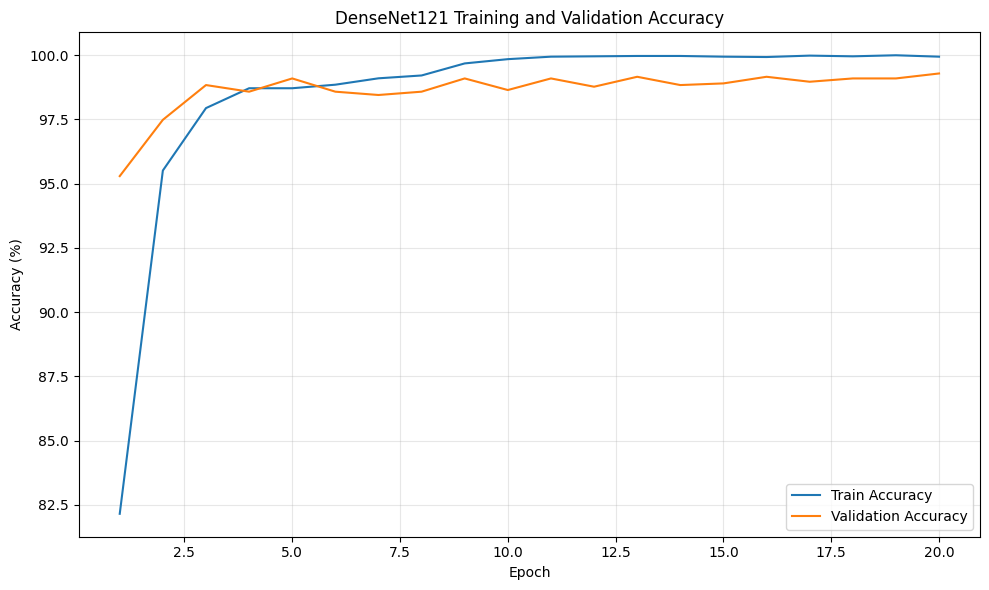

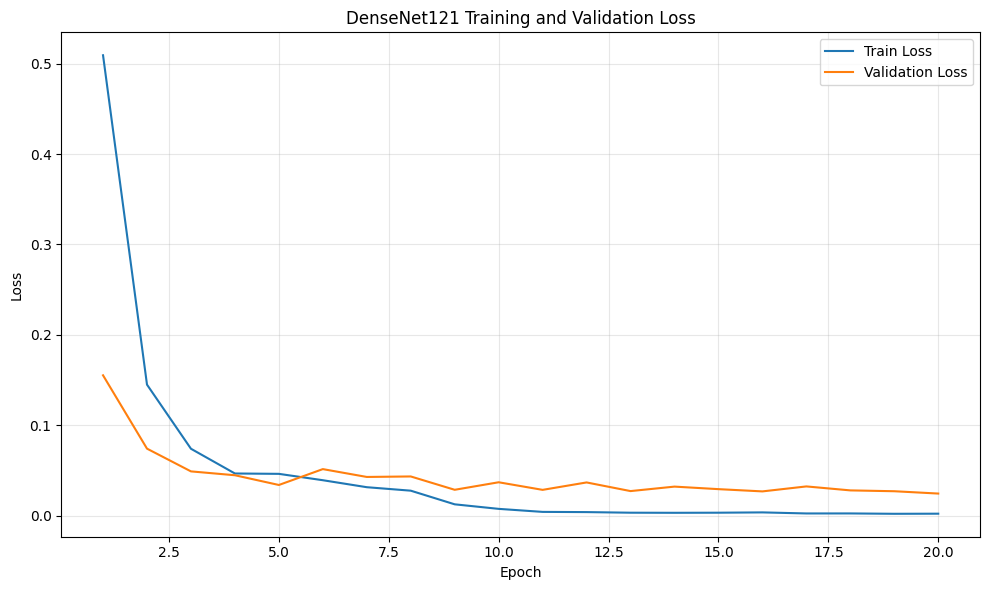

✓ Training curves saved


In [59]:
# ============================================================
# STEP 30 — TRAINING CURVES
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history_df["epoch"],
    history_df["train_accuracy"] * 100,
    label="Train Accuracy"
)

plt.plot(
    history_df["epoch"],
    history_df["val_accuracy"] * 100,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("DenseNet121 Training and Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

accuracy_curve_path = (
    DIRS["plots"]
    / "training_validation_accuracy.png"
)

plt.savefig(
    accuracy_curve_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DenseNet121 Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

loss_curve_path = (
    DIRS["plots"]
    / "training_validation_loss.png"
)

plt.savefig(
    loss_curve_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✓ Training curves saved")

In [60]:
# ============================================================
# STEP 31 — LOAD BEST MODEL
# ============================================================

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(DEVICE)

model.eval()

print("=" * 80)
print("BEST DENSENET121 LOADED")
print("=" * 80)

print(
    "Best epoch:",
    checkpoint["epoch"]
)

print(
    "Best validation accuracy:",
    f"{checkpoint['val_accuracy']*100:.2f}%"
)

BEST DENSENET121 LOADED
Best epoch: 20
Best validation accuracy: 99.29%


In [61]:
# ============================================================
# STEP 32 — COMPLETE TEST PREDICTION
# ============================================================

@torch.no_grad()
def predict_dataframe(
    model,
    dataframe,
    loader,
    device
):

    model.eval()

    all_labels = []
    all_predictions = []
    all_probabilities = []
    all_confidences = []

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        outputs = model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        confidences, predictions = (
            probabilities.max(dim=1)
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

        all_confidences.extend(
            confidences.cpu().numpy()
        )

    result = dataframe.copy().reset_index(
        drop=True
    )

    result["true_idx"] = np.array(
        all_labels
    )

    result["pred_idx"] = np.array(
        all_predictions
    )

    result["true_class"] = [
        IDX_TO_CLASS[x]
        for x in result["true_idx"]
    ]

    result["pred_class"] = [
        IDX_TO_CLASS[x]
        for x in result["pred_idx"]
    ]

    result["confidence"] = np.array(
        all_confidences
    )

    probabilities = np.array(
        all_probabilities
    )

    for idx, cls in enumerate(CLASS_NAMES):

        result[
            f"prob_{cls}"
        ] = probabilities[:, idx]

    result["correct"] = (
        result["true_idx"]
        ==
        result["pred_idx"]
    )

    return result

In [62]:
# ============================================================
# STEP 33 — OVERALL TEST PREDICTION
# ============================================================

test_results = predict_dataframe(
    model,
    test_df,
    test_loader,
    DEVICE
)

print("=" * 80)
print("TEST PREDICTION COMPLETE")
print("=" * 80)

print(
    "Test samples:",
    len(test_results)
)

print(
    "Correct:",
    test_results["correct"].sum()
)

print(
    "Incorrect:",
    (~test_results["correct"]).sum()
)

TEST PREDICTION COMPLETE
Test samples: 1871
Correct: 1861
Incorrect: 10


In [63]:
# ============================================================
# STEP 34 — OVERALL ACCURACY
# ============================================================

overall_accuracy = accuracy_score(
    test_results["true_idx"],
    test_results["pred_idx"]
)

print("=" * 80)
print("DENSENET121 OVERALL TEST PERFORMANCE")
print("=" * 80)

print(
    f"Overall Accuracy : "
    f"{overall_accuracy*100:.4f}%"
)

print(
    f"Correct          : "
    f"{test_results['correct'].sum():,}"
)

print(
    f"Incorrect        : "
    f"{(~test_results['correct']).sum():,}"
)

print(
    f"Test samples     : "
    f"{len(test_results):,}"
)

DENSENET121 OVERALL TEST PERFORMANCE
Overall Accuracy : 99.4655%
Correct          : 1,861
Incorrect        : 10
Test samples     : 1,871


In [64]:
# ============================================================
# STEP 35 — 95% BOOTSTRAP CONFIDENCE INTERVAL
# ============================================================

def bootstrap_accuracy_ci(
    y_true,
    y_pred,
    n_bootstrap=10000,
    seed=42
):

    rng = np.random.default_rng(seed)

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    n = len(y_true)

    bootstrap_scores = np.empty(
        n_bootstrap
    )

    for i in range(n_bootstrap):

        indices = rng.integers(
            0,
            n,
            size=n
        )

        bootstrap_scores[i] = np.mean(
            y_true[indices]
            ==
            y_pred[indices]
        )

    lower = np.percentile(
        bootstrap_scores,
        2.5
    )

    upper = np.percentile(
        bootstrap_scores,
        97.5
    )

    return (
        np.mean(bootstrap_scores),
        lower,
        upper
    )


boot_mean, ci_lower, ci_upper = (
    bootstrap_accuracy_ci(
        test_results["true_idx"].values,
        test_results["pred_idx"].values,
        n_bootstrap=10000,
        seed=SEED
    )
)

print("=" * 80)
print("95% BOOTSTRAP CONFIDENCE INTERVAL")
print("=" * 80)

print(
    f"Accuracy     : "
    f"{overall_accuracy*100:.4f}%"
)

print(
    f"Bootstrap mean: "
    f"{boot_mean*100:.4f}%"
)

print(
    f"95% CI        : "
    f"{ci_lower*100:.4f}% – "
    f"{ci_upper*100:.4f}%"
)

95% BOOTSTRAP CONFIDENCE INTERVAL
Accuracy     : 99.4655%
Bootstrap mean: 99.4651%
95% CI        : 99.0914% – 99.7862%


In [65]:
# ============================================================
# STEP 36 — ROBUST BANGLADESH vs INTERNATIONAL EVALUATION
# ============================================================

print("=" * 80)
print("BANGLADESH vs INTERNATIONAL TEST EVALUATION")
print("=" * 80)

# ------------------------------------------------------------
# 1. Basic validation
# ------------------------------------------------------------

required_test_columns = [
    "filename",
    "class",
    "source",
    "country",
    "dataset_group",
    "original_path"
]

missing_columns = [
    col
    for col in required_test_columns
    if col not in test_results.columns
]

if missing_columns:

    raise KeyError(
        f"Missing columns in test_results: {missing_columns}"
    )

# ------------------------------------------------------------
# 2. Verify prediction result length
# ------------------------------------------------------------

if len(test_results) != len(test_df):

    raise ValueError(
        f"""
PREDICTION / METADATA LENGTH MISMATCH

test_results = {len(test_results)}
test_df      = {len(test_df)}

DO NOT CONTINUE.
"""
    )

print(f"✓ Test prediction rows: {len(test_results):,}")

# ------------------------------------------------------------
# 3. Inspect source values
# ------------------------------------------------------------

print("\nSOURCE VALUES:")
print(
    test_results["source"]
    .value_counts(dropna=False)
)

print("\nCOUNTRY VALUES:")
print(
    test_results["country"]
    .value_counts(dropna=False)
)

print("\nDATASET GROUP VALUES:")
print(
    test_results["dataset_group"]
    .value_counts(dropna=False)
)

# ------------------------------------------------------------
# 4. Reconstruct groups DIRECTLY from test metadata
# ------------------------------------------------------------

bd_results = test_results[
    test_results["source"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("bangladesh")
].copy()

intl_results = test_results[
    test_results["source"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("international")
].copy()

# ------------------------------------------------------------
# 5. Validate complete coverage
# ------------------------------------------------------------

group_total = (
    len(bd_results)
    +
    len(intl_results)
)

print("\n" + "-" * 80)
print("GROUP COVERAGE")
print("-" * 80)

print(
    f"Overall test        : {len(test_results):,}"
)

print(
    f"Bangladesh test     : {len(bd_results):,}"
)

print(
    f"International test  : {len(intl_results):,}"
)

print(
    f"BD + International  : {group_total:,}"
)

if group_total != len(test_results):

    raise ValueError(
        f"""
GROUP COVERAGE ERROR

Overall test = {len(test_results)}
BD + Intl    = {group_total}

Some test samples have unknown source.
"""
    )

print("\n✓ Complete test coverage confirmed")

# ------------------------------------------------------------
# 6. Check group overlap
# ------------------------------------------------------------

bd_files = set(
    bd_results["filename"].astype(str)
)

intl_files = set(
    intl_results["filename"].astype(str)
)

overlap = bd_files & intl_files

print(
    "\nBD / International filename overlap:",
    len(overlap)
)

if overlap:

    print("⚠️ WARNING: filename overlap detected")

    for x in list(overlap)[:20]:
        print("→", x)

else:

    print("✓ No filename overlap")

# ------------------------------------------------------------
# 7. Accuracy
# ------------------------------------------------------------

bd_accuracy = accuracy_score(
    bd_results["true_idx"],
    bd_results["pred_idx"]
)

intl_accuracy = accuracy_score(
    intl_results["true_idx"],
    intl_results["pred_idx"]
)

print("\n" + "=" * 80)
print("BANGLADESH vs INTERNATIONAL RESULTS")
print("=" * 80)

print(
    f"Bangladesh samples    : {len(bd_results):,}"
)

print(
    f"Bangladesh correct    : "
    f"{bd_results['correct'].sum():,}"
)

print(
    f"Bangladesh incorrect  : "
    f"{(~bd_results['correct']).sum():,}"
)

print(
    f"Bangladesh accuracy   : "
    f"{bd_accuracy * 100:.4f}%"
)

print()

print(
    f"International samples : {len(intl_results):,}"
)

print(
    f"International correct : "
    f"{intl_results['correct'].sum():,}"
)

print(
    f"International incorrect: "
    f"{(~intl_results['correct']).sum():,}"
)

print(
    f"International accuracy : "
    f"{intl_accuracy * 100:.4f}%"
)

BANGLADESH vs INTERNATIONAL TEST EVALUATION
✓ Test prediction rows: 1,871

SOURCE VALUES:
source
International    1289
Bangladesh        582
Name: count, dtype: int64

COUNTRY VALUES:
country
International    1289
Bangladesh        582
Name: count, dtype: int64

DATASET GROUP VALUES:
dataset_group
International    1289
Bangladesh        582
Name: count, dtype: int64

--------------------------------------------------------------------------------
GROUP COVERAGE
--------------------------------------------------------------------------------
Overall test        : 1,871
Bangladesh test     : 582
International test  : 1,289
BD + International  : 1,871

✓ Complete test coverage confirmed

BD / International filename overlap: 0
✓ No filename overlap

BANGLADESH vs INTERNATIONAL RESULTS
Bangladesh samples    : 582
Bangladesh correct    : 575
Bangladesh incorrect  : 7
Bangladesh accuracy   : 98.7973%

International samples : 1,289
International correct : 1,286
International incorrect: 3
Inter

In [66]:
# ============================================================
# STEP 37 — SOURCE DISTRIBUTION
# ============================================================

print("=" * 80)
print("TEST SOURCE DISTRIBUTION")
print("=" * 80)

source_summary = (
    test_results
    .groupby("source")
    .agg(
        samples=("filename", "count"),
        correct=("correct", "sum")
    )
)

source_summary["incorrect"] = (
    source_summary["samples"]
    -
    source_summary["correct"]
)

source_summary["accuracy"] = (
    source_summary["correct"]
    /
    source_summary["samples"]
)

source_summary["accuracy_percent"] = (
    source_summary["accuracy"] * 100
)

display(source_summary)

TEST SOURCE DISTRIBUTION


,samples,correct,incorrect,accuracy,accuracy_percent
source,,,,,
Bangladesh,582,575,7,0.987973,98.797251
International,1289,1286,3,0.997673,99.767261


In [67]:
# ============================================================
# STEP 38 — COUNTRY DISTRIBUTION
# ============================================================

print("=" * 80)
print("TEST COUNTRY DISTRIBUTION")
print("=" * 80)

country_summary = (
    test_results
    .groupby("country")
    .agg(
        samples=("filename", "count"),
        correct=("correct", "sum")
    )
)

country_summary["incorrect"] = (
    country_summary["samples"]
    -
    country_summary["correct"]
)

country_summary["accuracy_percent"] = (
    country_summary["correct"]
    /
    country_summary["samples"]
    * 100
)

display(country_summary)

TEST COUNTRY DISTRIBUTION


,samples,correct,incorrect,accuracy_percent
country,,,,
Bangladesh,582,575,7,98.797251
International,1289,1286,3,99.767261


In [68]:
# ============================================================
# STEP 39 — CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import (
    classification_report,
    precision_recall_fscore_support
)

print("=" * 80)
print("DENSENET121 CLASSIFICATION REPORT")
print("=" * 80)

report = classification_report(
    test_results["true_idx"],
    test_results["pred_idx"],
    target_names=CLASS_NAMES,
    digits=4,
    output_dict=True
)

report_df = pd.DataFrame(report).T

display(report_df)

DENSENET121 CLASSIFICATION REPORT


,precision,recall,f1-score,support
Cardboard,0.992674,0.996324,0.994495,272.000000
Glass,0.997305,0.994624,0.995962,372.000000
Metal,0.997347,0.989474,0.993395,380.000000
Paper,0.997925,0.993802,0.995859,484.000000
Plastic,0.986413,1.000000,0.993160,363.000000
accuracy,0.994655,0.994655,0.994655,0.994655
macro avg,0.994333,0.994845,0.994574,1871.000000
weighted avg,0.994688,0.994655,0.994657,1871.000000


In [69]:
# ============================================================
# STEP 40 — SAVE CLASSIFICATION REPORT
# ============================================================

classification_report_path = (
    DIRS["logs"]
    / "densenet121_classification_report.csv"
)

report_df.to_csv(
    classification_report_path
)

print(
    "✓ Saved:",
    classification_report_path
)

✓ Saved: /kaggle/working/DenseNet121_Research_Results/logs/densenet121_classification_report.csv


In [70]:
# ============================================================
# STEP 37 — PER-CLASS ACCURACY
# ============================================================

per_class_rows = []

for cls in CLASS_NAMES:

    subset = test_results[
        test_results["true_class"] == cls
    ]

    class_accuracy = (
        subset["correct"].mean()
    )

    per_class_rows.append({

        "class": cls,

        "support": len(subset),

        "correct": int(
            subset["correct"].sum()
        ),

        "incorrect": int(
            (~subset["correct"]).sum()
        ),

        "accuracy": class_accuracy,

        "accuracy_percent":
            class_accuracy * 100

    })

per_class_accuracy_df = pd.DataFrame(
    per_class_rows
)

print(
    per_class_accuracy_df.to_string(
        index=False
    )
)

    class  support  correct  incorrect  accuracy  accuracy_percent
Cardboard      272      271          1  0.996324         99.632353
    Glass      372      370          2  0.994624         99.462366
    Metal      380      376          4  0.989474         98.947368
    Paper      484      481          3  0.993802         99.380165
  Plastic      363      363          0  1.000000        100.000000


In [71]:
# ============================================================
# STEP 38 — PER-CLASS F1
# ============================================================

report_dict = classification_report(
    test_results["true_idx"],
    test_results["pred_idx"],
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

per_class_f1_df = pd.DataFrame({

    "class": CLASS_NAMES,

    "precision": [
        report_dict[c]["precision"]
        for c in CLASS_NAMES
    ],

    "recall": [
        report_dict[c]["recall"]
        for c in CLASS_NAMES
    ],

    "f1": [
        report_dict[c]["f1-score"]
        for c in CLASS_NAMES
    ],

    "support": [
        report_dict[c]["support"]
        for c in CLASS_NAMES
    ]

})

print(
    per_class_f1_df.to_string(
        index=False
    )
)

    class  precision   recall       f1  support
Cardboard   0.992674 0.996324 0.994495    272.0
    Glass   0.997305 0.994624 0.995962    372.0
    Metal   0.997347 0.989474 0.993395    380.0
    Paper   0.997925 0.993802 0.995859    484.0
  Plastic   0.986413 1.000000 0.993160    363.0


In [72]:
# ============================================================
# STEP 39 — CLASSIFICATION REPORT
# ============================================================

print("=" * 80)
print("DENSENET121 CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        test_results["true_idx"],
        test_results["pred_idx"],
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)

classification_report_df = pd.DataFrame(
    report_dict
).transpose()

classification_report_df.to_csv(
    DIRS["metrics"]
    / "classification_report.csv"
)

DENSENET121 CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Cardboard     0.9927    0.9963    0.9945       272
       Glass     0.9973    0.9946    0.9960       372
       Metal     0.9973    0.9895    0.9934       380
       Paper     0.9979    0.9938    0.9959       484
     Plastic     0.9864    1.0000    0.9932       363

    accuracy                         0.9947      1871
   macro avg     0.9943    0.9948    0.9946      1871
weighted avg     0.9947    0.9947    0.9947      1871



CONFUSION MATRIX


,Cardboard,Glass,Metal,Paper,Plastic
Cardboard,271,0,0,1,0
Glass,0,370,1,0,1
Metal,0,1,376,0,3
Paper,2,0,0,481,1
Plastic,0,0,0,0,363


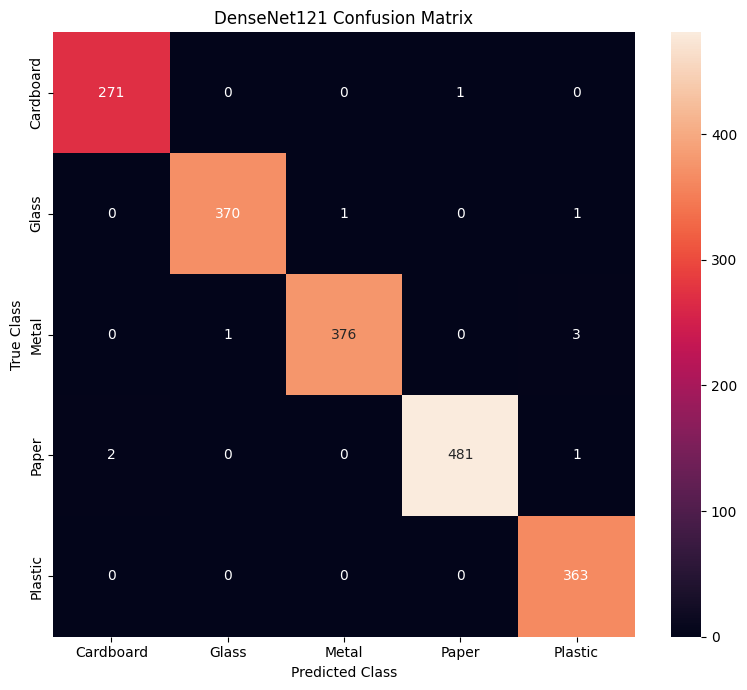

In [73]:
# ============================================================
# STEP 40 — CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    test_results["true_idx"],
    test_results["pred_idx"],
    labels=list(range(len(CLASS_NAMES)))
)

print("=" * 80)
print("CONFUSION MATRIX")
print("=" * 80)

cm_df = pd.DataFrame(
    cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)

display(cm_df)

cm_df.to_csv(
    DIRS["confusion"]
    / "confusion_matrix.csv"
)

plt.figure(
    figsize=(8, 7)
)

sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("DenseNet121 Confusion Matrix")

plt.tight_layout()

plt.savefig(
    DIRS["confusion"]
    / "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

CONFUSION MATRIX


,Cardboard,Glass,Metal,Paper,Plastic
Cardboard,271,0,0,1,0
Glass,0,370,1,0,1
Metal,0,1,376,0,3
Paper,2,0,0,481,1
Plastic,0,0,0,0,363


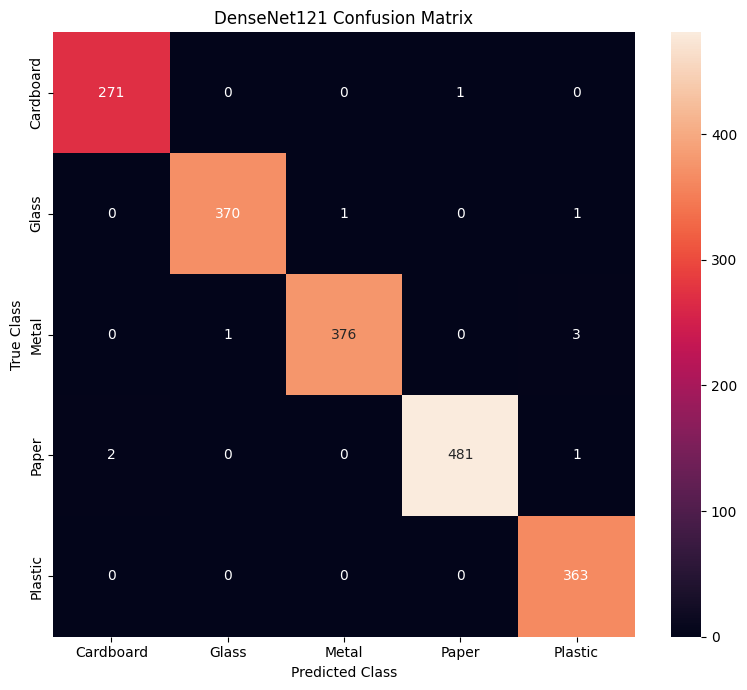

In [74]:
# ============================================================
# STEP 40 — CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    test_results["true_idx"],
    test_results["pred_idx"],
    labels=list(range(len(CLASS_NAMES)))
)

print("=" * 80)
print("CONFUSION MATRIX")
print("=" * 80)

cm_df = pd.DataFrame(
    cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)

display(cm_df)

cm_df.to_csv(
    DIRS["confusion"]
    / "confusion_matrix.csv"
)

plt.figure(
    figsize=(8, 7)
)

sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("DenseNet121 Confusion Matrix")

plt.tight_layout()

plt.savefig(
    DIRS["confusion"]
    / "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

GROUP × CLASS ACCURACY


class,Cardboard,Glass,Metal,Paper,Plastic
group,,,,,
Bangladesh,95.83,99.17,94.59,99.46,100.0
International,100.00,99.60,100.00,99.33,100.0


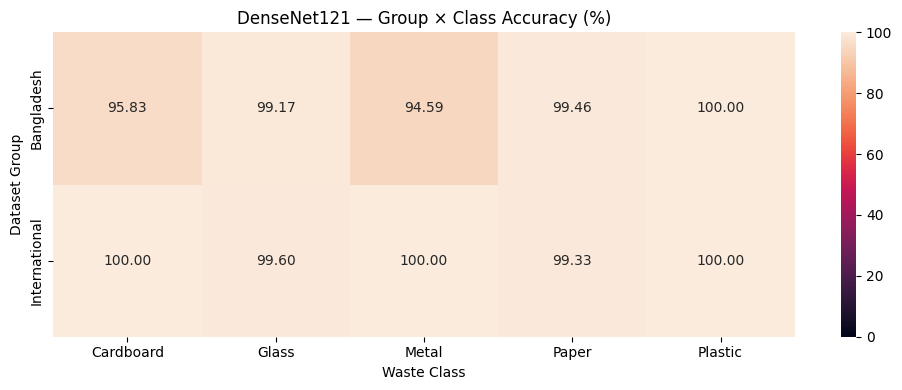

In [75]:
# ============================================================
# STEP 42 — GROUP × CLASS ACCURACY HEATMAP
# ============================================================

group_class_rows = []

for group_name, group_df in [
    ("Bangladesh", bd_results),
    ("International", intl_results)
]:

    for cls in CLASS_NAMES:

        subset = group_df[
            group_df["true_class"] == cls
        ]

        accuracy = (
            subset["correct"].mean()
            if len(subset) > 0
            else np.nan
        )

        group_class_rows.append({

            "group": group_name,
            "class": cls,
            "accuracy": accuracy * 100,
            "support": len(subset)

        })

group_class_df = pd.DataFrame(
    group_class_rows
)

group_heatmap = (
    group_class_df
    .pivot(
        index="group",
        columns="class",
        values="accuracy"
    )
)

print("=" * 80)
print("GROUP × CLASS ACCURACY")
print("=" * 80)

display(
    group_heatmap.round(2)
)

group_heatmap.to_csv(
    DIRS["metrics"]
    / "group_class_accuracy.csv"
)

plt.figure(
    figsize=(10, 4)
)

sns.heatmap(
    group_heatmap,
    annot=True,
    fmt=".2f",
    vmin=0,
    vmax=100
)

plt.xlabel("Waste Class")
plt.ylabel("Dataset Group")
plt.title(
    "DenseNet121 — Group × Class Accuracy (%)"
)

plt.tight_layout()

plt.savefig(
    DIRS["plots"]
    / "group_class_accuracy_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

ERROR PAIRS


,true_class,pred_class,count
4,Metal,Plastic,3
5,Paper,Cardboard,2
0,Cardboard,Paper,1
2,Glass,Plastic,1
1,Glass,Metal,1
3,Metal,Glass,1
6,Paper,Plastic,1


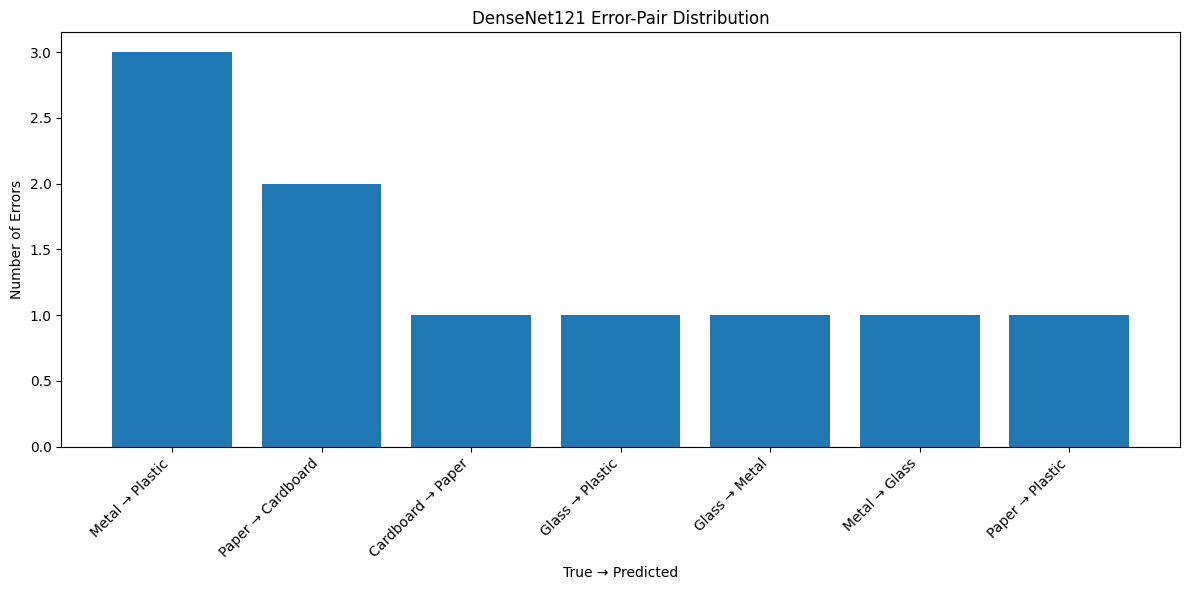

In [76]:
# ============================================================
# STEP 43 — ERROR PAIR ANALYSIS
# ============================================================

errors = test_results[
    ~test_results["correct"]
].copy()

error_pairs = (
    errors
    .groupby(
        ["true_class", "pred_class"]
    )
    .size()
    .reset_index(
        name="count"
    )
    .sort_values(
        "count",
        ascending=False
    )
)

print("=" * 80)
print("ERROR PAIRS")
print("=" * 80)

display(error_pairs)

error_pairs.to_csv(
    DIRS["errors"]
    / "error_pairs.csv",
    index=False
)

plt.figure(
    figsize=(12, 6)
)

labels = (
    error_pairs["true_class"]
    + " → "
    + error_pairs["pred_class"]
)

plt.bar(
    labels,
    error_pairs["count"]
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.xlabel("True → Predicted")
plt.ylabel("Number of Errors")
plt.title(
    "DenseNet121 Error-Pair Distribution"
)

plt.tight_layout()

plt.savefig(
    DIRS["plots"]
    / "error_pair_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

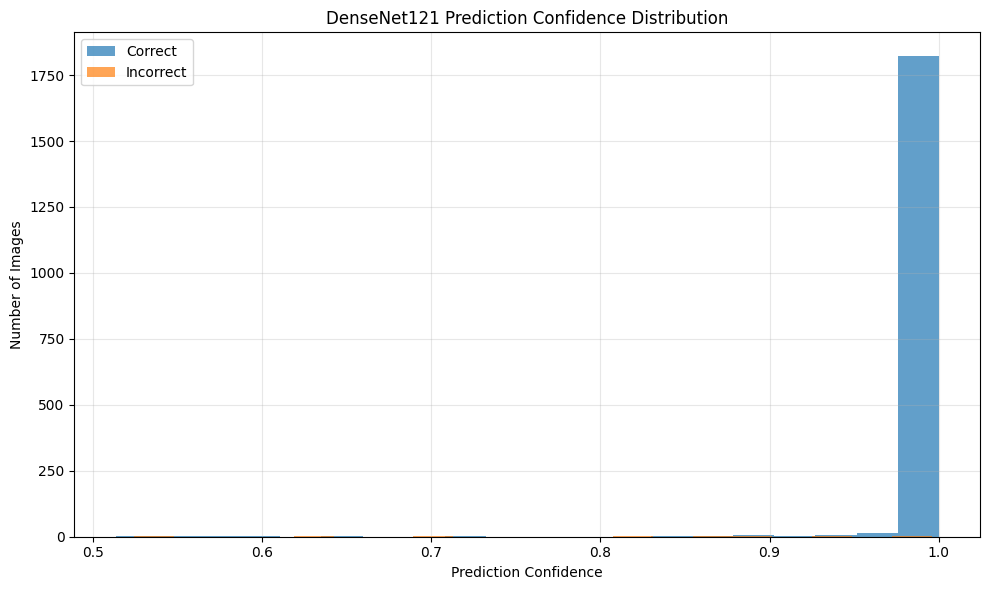

In [77]:
# ============================================================
# STEP 44 — CONFIDENCE DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.hist(
    test_results[
        test_results["correct"]
    ]["confidence"],
    bins=20,
    alpha=0.7,
    label="Correct"
)

plt.hist(
    test_results[
        ~test_results["correct"]
    ]["confidence"],
    bins=20,
    alpha=0.7,
    label="Incorrect"
)

plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Images")

plt.title(
    "DenseNet121 Prediction Confidence Distribution"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    DIRS["plots"]
    / "confidence_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

CALIBRATION
ECE: 0.003094


,bin_lower,bin_upper,count,confidence,accuracy
0,0.5,0.6,9,0.5554,0.7778
1,0.6,0.7,3,0.6570,0.3333
2,0.7,0.8,1,0.7310,1.0000
3,0.8,0.9,11,0.8710,0.7273
4,0.9,1.0,1847,0.9989,0.9984


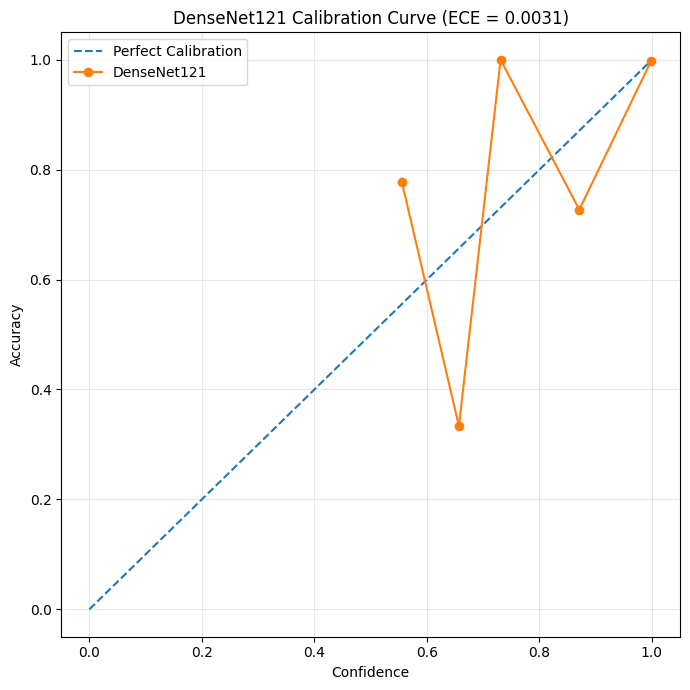

In [78]:
# ============================================================
# STEP 45 — CALIBRATION / ECE
# ============================================================

def expected_calibration_error(
    confidences,
    correct,
    n_bins=10
):

    confidences = np.asarray(
        confidences
    )

    correct = np.asarray(
        correct
    ).astype(float)

    bin_edges = np.linspace(
        0.0,
        1.0,
        n_bins + 1
    )

    ece = 0.0

    rows = []

    for i in range(n_bins):

        lower = bin_edges[i]
        upper = bin_edges[i + 1]

        if i == n_bins - 1:

            mask = (
                (confidences >= lower)
                &
                (confidences <= upper)
            )

        else:

            mask = (
                (confidences >= lower)
                &
                (confidences < upper)
            )

        if mask.sum() == 0:

            continue

        bin_confidence = (
            confidences[mask].mean()
        )

        bin_accuracy = (
            correct[mask].mean()
        )

        bin_count = mask.sum()

        ece += (
            bin_count
            /
            len(confidences)
        ) * abs(
            bin_accuracy
            -
            bin_confidence
        )

        rows.append({

            "bin_lower": lower,
            "bin_upper": upper,
            "count": bin_count,
            "confidence": bin_confidence,
            "accuracy": bin_accuracy

        })

    return ece, pd.DataFrame(rows)


ece, calibration_df = (
    expected_calibration_error(
        test_results["confidence"].values,
        test_results["correct"].values,
        n_bins=10
    )
)

print("=" * 80)
print("CALIBRATION")
print("=" * 80)

print(
    f"ECE: {ece:.6f}"
)

display(
    calibration_df.round(4)
)

calibration_df.to_csv(
    DIRS["metrics"]
    / "calibration_bins.csv",
    index=False
)

plt.figure(
    figsize=(7, 7)
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.plot(
    calibration_df["confidence"],
    calibration_df["accuracy"],
    marker="o",
    label="DenseNet121"
)

plt.xlabel("Confidence")
plt.ylabel("Accuracy")

plt.title(
    f"DenseNet121 Calibration Curve "
    f"(ECE = {ece:.4f})"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    DIRS["plots"]
    / "calibration_ece.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

CALIBRATION
ECE: 0.003094


,bin_lower,bin_upper,count,confidence,accuracy
0,0.5,0.6,9,0.5554,0.7778
1,0.6,0.7,3,0.6570,0.3333
2,0.7,0.8,1,0.7310,1.0000
3,0.8,0.9,11,0.8710,0.7273
4,0.9,1.0,1847,0.9989,0.9984


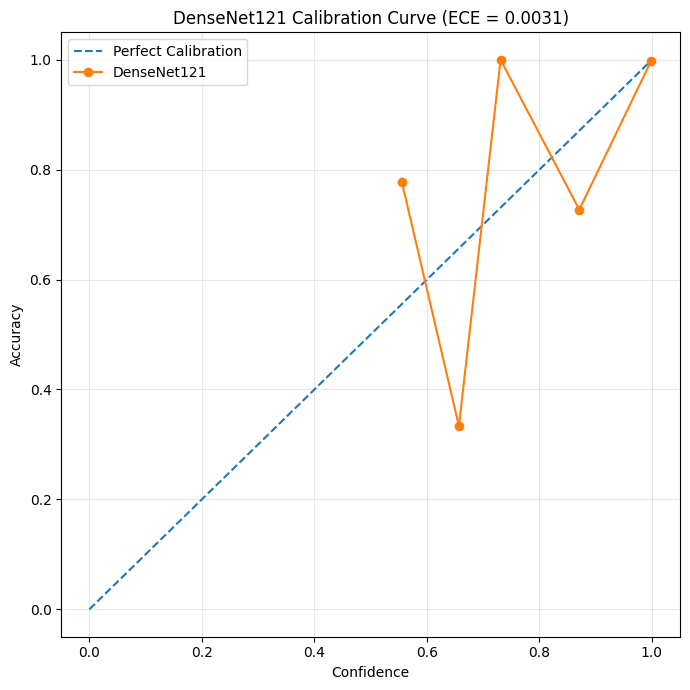

In [79]:
# ============================================================
# STEP 45 — CALIBRATION / ECE
# ============================================================

def expected_calibration_error(
    confidences,
    correct,
    n_bins=10
):

    confidences = np.asarray(
        confidences
    )

    correct = np.asarray(
        correct
    ).astype(float)

    bin_edges = np.linspace(
        0.0,
        1.0,
        n_bins + 1
    )

    ece = 0.0

    rows = []

    for i in range(n_bins):

        lower = bin_edges[i]
        upper = bin_edges[i + 1]

        if i == n_bins - 1:

            mask = (
                (confidences >= lower)
                &
                (confidences <= upper)
            )

        else:

            mask = (
                (confidences >= lower)
                &
                (confidences < upper)
            )

        if mask.sum() == 0:

            continue

        bin_confidence = (
            confidences[mask].mean()
        )

        bin_accuracy = (
            correct[mask].mean()
        )

        bin_count = mask.sum()

        ece += (
            bin_count
            /
            len(confidences)
        ) * abs(
            bin_accuracy
            -
            bin_confidence
        )

        rows.append({

            "bin_lower": lower,
            "bin_upper": upper,
            "count": bin_count,
            "confidence": bin_confidence,
            "accuracy": bin_accuracy

        })

    return ece, pd.DataFrame(rows)


ece, calibration_df = (
    expected_calibration_error(
        test_results["confidence"].values,
        test_results["correct"].values,
        n_bins=10
    )
)

print("=" * 80)
print("CALIBRATION")
print("=" * 80)

print(
    f"ECE: {ece:.6f}"
)

display(
    calibration_df.round(4)
)

calibration_df.to_csv(
    DIRS["metrics"]
    / "calibration_bins.csv",
    index=False
)

plt.figure(
    figsize=(7, 7)
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.plot(
    calibration_df["confidence"],
    calibration_df["accuracy"],
    marker="o",
    label="DenseNet121"
)

plt.xlabel("Confidence")
plt.ylabel("Accuracy")

plt.title(
    f"DenseNet121 Calibration Curve "
    f"(ECE = {ece:.4f})"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    DIRS["plots"]
    / "calibration_ece.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [80]:
# ============================================================
# STEP 47 — MISCLASSIFIED IMAGE GALLERY DATA
# ============================================================

misclassified = test_results[
    ~test_results["correct"]
].copy()

misclassified = (
    misclassified
    .sort_values(
        "confidence",
        ascending=False
    )
)

N_GALLERY = min(
    14,
    len(misclassified)
)

gallery_df = misclassified.head(
    N_GALLERY
).copy()

print("=" * 80)
print("MISCLASSIFIED IMAGE GALLERY")
print("=" * 80)

print(
    f"Available errors : {len(misclassified)}"
)

print(
    f"Gallery images   : {N_GALLERY}"
)

MISCLASSIFIED IMAGE GALLERY
Available errors : 10
Gallery images   : 10


In [81]:
# ============================================================
# STEP 47 — MISCLASSIFIED IMAGE GALLERY DATA
# ============================================================

misclassified = test_results[
    ~test_results["correct"]
].copy()

misclassified = (
    misclassified
    .sort_values(
        "confidence",
        ascending=False
    )
)

N_GALLERY = min(
    14,
    len(misclassified)
)

gallery_df = misclassified.head(
    N_GALLERY
).copy()

print("=" * 80)
print("MISCLASSIFIED IMAGE GALLERY")
print("=" * 80)

print(
    f"Available errors : {len(misclassified)}"
)

print(
    f"Gallery images   : {N_GALLERY}"
)

MISCLASSIFIED IMAGE GALLERY
Available errors : 10
Gallery images   : 10


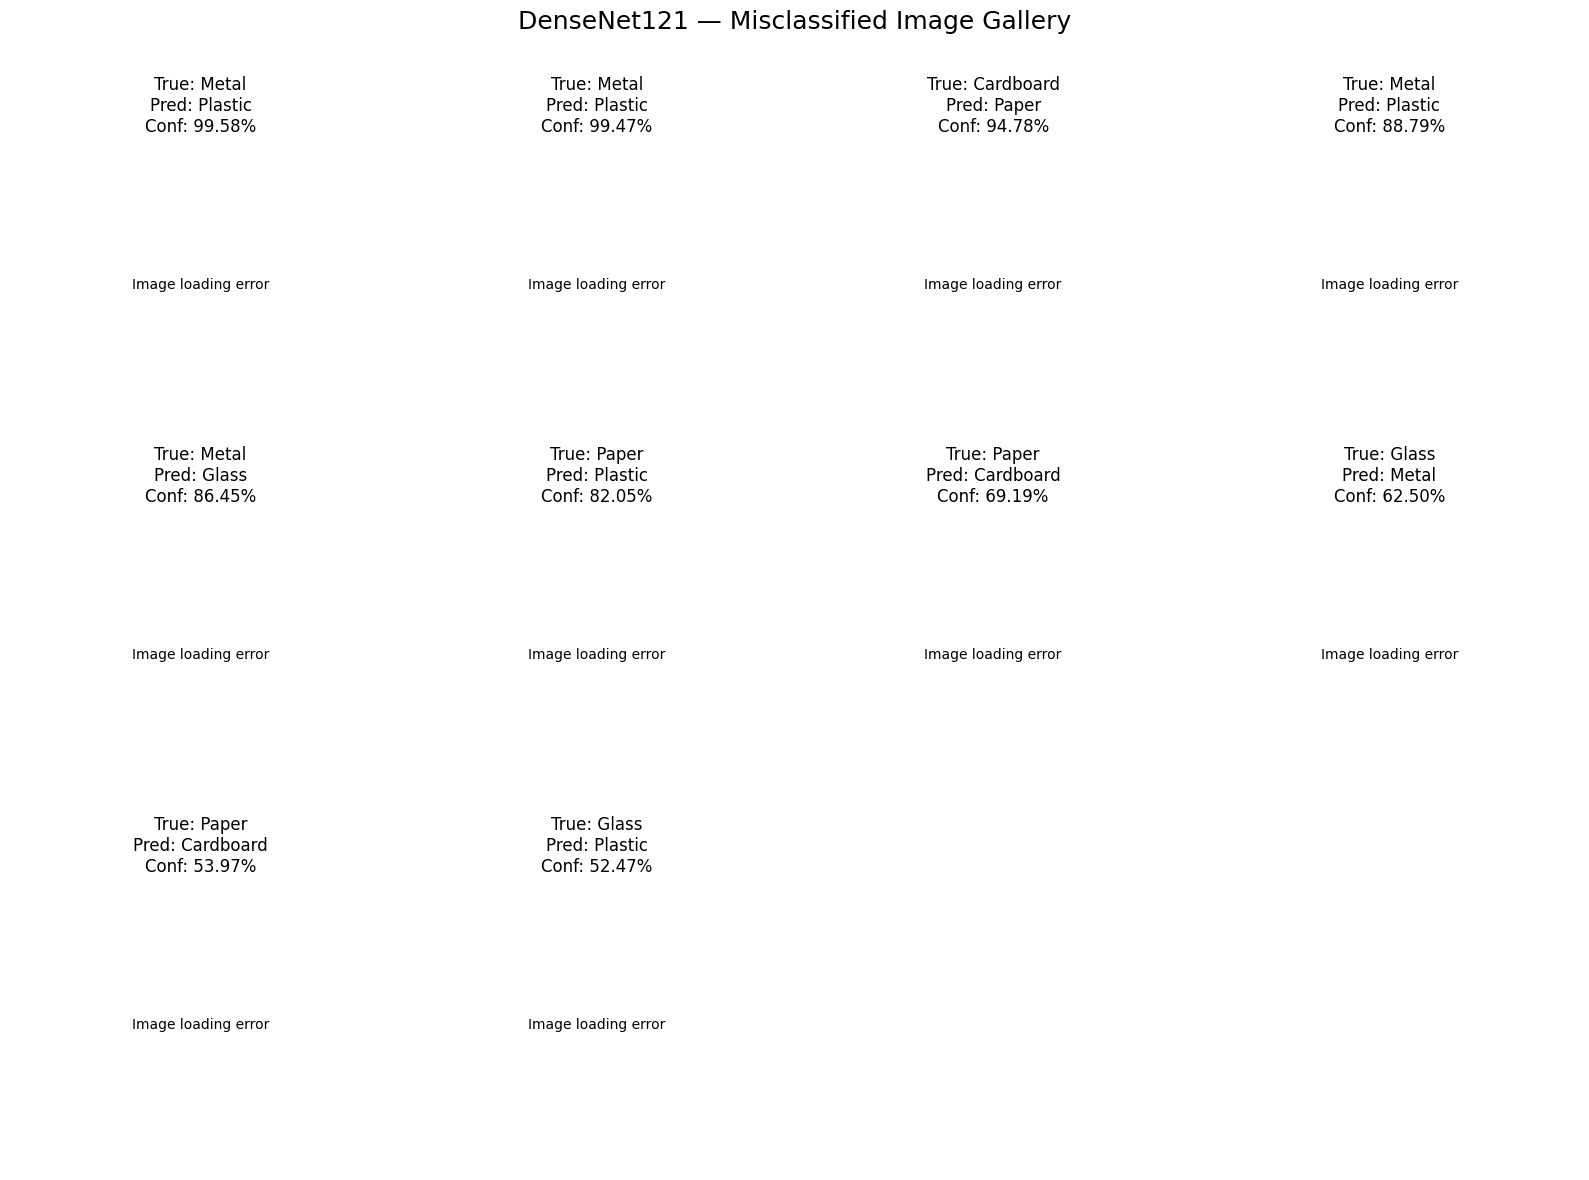

Gallery saved: /kaggle/working/DenseNet121_Research_Results/misclassified_gallery/densenet121_misclassified_14.png


In [82]:
# ============================================================
# STEP 49 — VISUAL GALLERY
# ============================================================

cols = 4
rows = math.ceil(
    N_GALLERY / cols
)

plt.figure(
    figsize=(16, 4 * rows)
)

for i, (_, row) in enumerate(
    gallery_df.iterrows()
):

    ax = plt.subplot(
        rows,
        cols,
        i + 1
    )

    try:

        image = Image.open(
            row["image_path"]
        ).convert("RGB")

        ax.imshow(image)

    except Exception:

        ax.text(
            0.5,
            0.5,
            "Image loading error",
            ha="center",
            va="center"
        )

    ax.set_title(
        f"True: {row['true_class']}\n"
        f"Pred: {row['pred_class']}\n"
        f"Conf: {row['confidence']:.2%}"
    )

    ax.axis("off")

plt.suptitle(
    "DenseNet121 — Misclassified Image Gallery",
    fontsize=18
)

plt.tight_layout(
    rect=[0, 0, 1, 0.97]
)

gallery_path = (
    DIRS["gallery"]
    / "densenet121_misclassified_14.png"
)

plt.savefig(
    gallery_path,
    dpi=250,
    bbox_inches="tight"
)

plt.show()

print(
    "Gallery saved:",
    gallery_path
)

In [83]:
# ============================================================
# STEP 50 — SAVE ALL TEST PREDICTIONS
# ============================================================

prediction_path = (
    DIRS["metrics"]
    / "densenet121_test_predictions.csv"
)

test_results.to_csv(
    prediction_path,
    index=False
)

print(
    "Saved:",
    prediction_path
)

Saved: /kaggle/working/DenseNet121_Research_Results/metrics/densenet121_test_predictions.csv


In [84]:
# ============================================================
# STEP 51 — SAVE GROUP RESULTS
# ============================================================

bd_results.to_csv(
    DIRS["metrics"]
    / "densenet121_bangladesh_predictions.csv",
    index=False
)

intl_results.to_csv(
    DIRS["metrics"]
    / "densenet121_international_predictions.csv",
    index=False
)

print("✓ Bangladesh predictions saved")
print("✓ International predictions saved")

✓ Bangladesh predictions saved
✓ International predictions saved


In [85]:
# ============================================================
# STEP 52 — GROUP CLASSIFICATION REPORTS
# ============================================================
import pandas as pd
bd_report = pd.DataFrame(
    classification_report(
        bd_results["true_idx"],
        bd_results["pred_idx"],
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )
).transpose()

intl_report = pd.DataFrame(
    classification_report(
        intl_results["true_idx"],
        intl_results["pred_idx"],
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )
).transpose()

bd_report.to_csv(
    DIRS["metrics"]
    / "bangladesh_classification_report.csv"
)

intl_report.to_csv(
    DIRS["metrics"]
    / "international_classification_report.csv"
)

print("=" * 80)
print("BANGLADESH REPORT")
print("=" * 80)

display(
    bd_report.round(4)
)

print("=" * 80)
print("INTERNATIONAL REPORT")
print("=" * 80)

display(
    intl_report.round(4)
)

BANGLADESH REPORT


,precision,recall,f1-score,support
Cardboard,1.0000,0.9583,0.9787,24.000
Glass,0.9917,0.9917,0.9917,120.000
Metal,1.0000,0.9459,0.9722,74.000
Paper,0.9946,0.9946,0.9946,184.000
Plastic,0.9730,1.0000,0.9863,180.000
accuracy,0.9880,0.9880,0.9880,0.988
macro avg,0.9918,0.9781,0.9847,582.000
weighted avg,0.9882,0.9880,0.9879,582.000


INTERNATIONAL REPORT


,precision,recall,f1-score,support
Cardboard,0.9920,1.0000,0.9960,248.0000
Glass,1.0000,0.9960,0.9980,252.0000
Metal,0.9967,1.0000,0.9984,306.0000
Paper,1.0000,0.9933,0.9967,300.0000
Plastic,1.0000,1.0000,1.0000,183.0000
accuracy,0.9977,0.9977,0.9977,0.9977
macro avg,0.9977,0.9979,0.9978,1289.0000
weighted avg,0.9977,0.9977,0.9977,1289.0000


In [86]:
# ============================================================
# STEP 53 — HIGH-CONFIDENCE ERROR ANALYSIS
# ============================================================

print("=" * 80)
print("HIGH-CONFIDENCE ERROR ANALYSIS")
print("=" * 80)

# Define threshold
HIGH_CONF_THRESHOLD = 0.90

# Make sure confidence is numeric
test_results["confidence"] = pd.to_numeric(
    test_results["confidence"],
    errors="coerce"
)

# High-confidence incorrect predictions
high_conf_errors = test_results[
    (~test_results["correct"]) &
    (test_results["confidence"] >= HIGH_CONF_THRESHOLD)
].copy()

print(
    f"Threshold             : {HIGH_CONF_THRESHOLD:.0%}"
)

print(
    f"Total test samples    : {len(test_results):,}"
)

print(
    f"Total errors          : "
    f"{(~test_results['correct']).sum():,}"
)

print(
    f"High-confidence errors: "
    f"{len(high_conf_errors):,}"
)

if len(high_conf_errors) > 0:

    print("\nHigh-confidence errors:")
    
    display(
        high_conf_errors[
            [
                "filename",
                "true_class",
                "pred_class",
                "confidence"
            ]
        ].sort_values(
            "confidence",
            ascending=False
        )
    )

else:

    print(
        "\n✓ No high-confidence errors found."
    )

HIGH-CONFIDENCE ERROR ANALYSIS
Threshold             : 90%
Total test samples    : 1,871
Total errors          : 10
High-confidence errors: 3

High-confidence errors:


,filename,true_class,pred_class,confidence
748,BD__EWaste__train__IMG_20250805_204201_jpg.rf....,Metal,Plastic,0.995807
954,BD__EWaste__test__IMG_20250805_204159_jpg.rf.3...,Metal,Plastic,0.994687
679,BD__BDWaste__Bangladesh_Cardboard__000009.jpg,Cardboard,Paper,0.947753


In [87]:
# ============================================================
# STEP 54 — COMPLETE FINAL METRICS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

y_true = test_results["true_idx"].astype(int)
y_pred = test_results["pred_idx"].astype(int)

# ------------------------------------------------------------
# Overall metrics
# ------------------------------------------------------------

overall_accuracy = accuracy_score(
    y_true,
    y_pred
)

macro_precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

weighted_precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

weighted_recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

# ------------------------------------------------------------
# Error count
# ------------------------------------------------------------

total_errors = int(
    (~test_results["correct"]).sum()
)

total_samples = len(test_results)

error_rate = (
    total_errors / total_samples
)

# ------------------------------------------------------------
# Group accuracy
# ------------------------------------------------------------

bd_accuracy = accuracy_score(
    bd_results["true_idx"],
    bd_results["pred_idx"]
)

intl_accuracy = accuracy_score(
    intl_results["true_idx"],
    intl_results["pred_idx"]
)

# ------------------------------------------------------------
# Print
# ------------------------------------------------------------

print("=" * 80)
print("FINAL DENSENET121 METRICS")
print("=" * 80)

print(f"Test Samples          : {total_samples:,}")
print(f"Correct Predictions   : {total_samples - total_errors:,}")
print(f"Incorrect Predictions : {total_errors:,}")

print("-" * 80)

print(
    f"Accuracy              : "
    f"{overall_accuracy * 100:.4f}%"
)

print(
    f"Macro Precision       : "
    f"{macro_precision:.4f}"
)

print(
    f"Macro Recall          : "
    f"{macro_recall:.4f}"
)

print(
    f"Macro F1              : "
    f"{macro_f1:.4f}"
)

print(
    f"Weighted Precision    : "
    f"{weighted_precision:.4f}"
)

print(
    f"Weighted Recall       : "
    f"{weighted_recall:.4f}"
)

print(
    f"Weighted F1          : "
    f"{weighted_f1:.4f}"
)

print("-" * 80)

print(
    f"Bangladesh Accuracy   : "
    f"{bd_accuracy * 100:.4f}%"
)

print(
    f"International Accuracy: "
    f"{intl_accuracy * 100:.4f}%"
)

print(
    f"Error Rate            : "
    f"{error_rate * 100:.4f}%"
)

print(
    f"ECE                   : "
    f"{ece:.6f}"
)

print(
    f"High-Confidence Errors: "
    f"{len(high_conf_errors):,}"
)

FINAL DENSENET121 METRICS
Test Samples          : 1,871
Correct Predictions   : 1,861
Incorrect Predictions : 10
--------------------------------------------------------------------------------
Accuracy              : 99.4655%
Macro Precision       : 0.9943
Macro Recall          : 0.9948
Macro F1              : 0.9946
Weighted Precision    : 0.9947
Weighted Recall       : 0.9947
Weighted F1          : 0.9947
--------------------------------------------------------------------------------
Bangladesh Accuracy   : 98.7973%
International Accuracy: 99.7673%
Error Rate            : 0.5345%
ECE                   : 0.003094
High-Confidence Errors: 3


In [88]:
# ============================================================
# STEP 53 — FINAL RESEARCH SUMMARY
# ============================================================

macro_f1 = f1_score(
    test_results["true_idx"],
    test_results["pred_idx"],
    average="macro"
)

weighted_f1 = f1_score(
    test_results["true_idx"],
    test_results["pred_idx"],
    average="weighted"
)

macro_precision = precision_score(
    test_results["true_idx"],
    test_results["pred_idx"],
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    test_results["true_idx"],
    test_results["pred_idx"],
    average="macro",
    zero_division=0
)

summary = {

    "model": "DenseNet121",

    "dataset": {
        "total_images": len(final_df),
        "train": len(train_df),
        "validation": len(val_df),
        "test": len(test_df),
        "bangladesh_test": len(bd_results),
        "international_test": len(intl_results)
    },

    "configuration": {
        "image_size": IMG_SIZE,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "seed": SEED,
        "optimizer": "AdamW",
        "learning_rate": 1e-4,
        "loss": "Weighted CrossEntropyLoss"
    },

    "performance": {

        "overall_accuracy": overall_accuracy,

        "overall_accuracy_percent":
            overall_accuracy * 100,

        "bootstrap_95_ci_lower":
            ci_lower,

        "bootstrap_95_ci_upper":
            ci_upper,

        "bootstrap_95_ci_percent": [
            ci_lower * 100,
            ci_upper * 100
        ],

        "bangladesh_accuracy":
            bd_accuracy,

        "bangladesh_accuracy_percent":
            bd_accuracy * 100,

        "international_accuracy":
            intl_accuracy,

        "international_accuracy_percent":
            intl_accuracy * 100,

        "macro_f1": macro_f1,

        "weighted_f1": weighted_f1,

        "macro_precision":
            macro_precision,

        "macro_recall":
            macro_recall,

        "ece": ece,

        "misclassified_images":
            int((~test_results["correct"]).sum()),

        "high_confidence_errors":
            len(high_conf_errors)
    },

    "best_epoch":
        int(checkpoint["epoch"]),

    "best_validation_accuracy":
        float(
            checkpoint["val_accuracy"]
        ),

    "model_parameters":
        int(total_params)

}

summary_path = (
    DIRS["metrics"]
    / "densenet121_final_summary.json"
)

with open(
    summary_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary,
        f,
        indent=4,
        ensure_ascii=False
    )

print("=" * 80)
print("DENSENET121 FINAL RESEARCH SUMMARY")
print("=" * 80)

print(
    f"Overall Accuracy      : "
    f"{overall_accuracy*100:.4f}%"
)

print(
    f"95% CI                : "
    f"{ci_lower*100:.4f}% – "
    f"{ci_upper*100:.4f}%"
)

print(
    f"Bangladesh Accuracy   : "
    f"{bd_accuracy*100:.4f}% "
    f"({len(bd_results):,})"
)

print(
    f"International Accuracy: "
    f"{intl_accuracy*100:.4f}% "
    f"({len(intl_results):,})"
)

print(
    f"Macro F1              : "
    f"{macro_f1:.4f}"
)

print(
    f"Weighted F1           : "
    f"{weighted_f1:.4f}"
)

print(
    f"ECE                   : "
    f"{ece:.6f}"
)

print(
    f"Misclassified         : "
    f"{(~test_results['correct']).sum():,}"
)

print(
    f"High-conf errors      : "
    f"{len(high_conf_errors):,}"
)

print(
    "\nSummary saved:",
    summary_path
)

DENSENET121 FINAL RESEARCH SUMMARY
Overall Accuracy      : 99.4655%
95% CI                : 99.0914% – 99.7862%
Bangladesh Accuracy   : 98.7973% (582)
International Accuracy: 99.7673% (1,289)
Macro F1              : 0.9946
Weighted F1           : 0.9947
ECE                   : 0.003094
Misclassified         : 10
High-conf errors      : 3

Summary saved: /kaggle/working/DenseNet121_Research_Results/metrics/densenet121_final_summary.json


In [89]:
# ============================================================
# STEP 54 — FINAL PER-CLASS TABLE
# ============================================================

final_per_class = (
    per_class_accuracy_df
    .merge(
        per_class_f1_df[
            [
                "class",
                "precision",
                "recall",
                "f1"
            ]
        ],
        on="class"
    )
)

final_per_class = final_per_class[
    [
        "class",
        "support",
        "correct",
        "incorrect",
        "accuracy_percent",
        "precision",
        "recall",
        "f1"
    ]
]

display(
    final_per_class.round(4)
)

final_per_class.to_csv(
    DIRS["metrics"]
    / "final_per_class_metrics.csv",
    index=False
)

,class,support,correct,incorrect,accuracy_percent,precision,recall,f1
0,Cardboard,272,271,1,99.6324,0.9927,0.9963,0.9945
1,Glass,372,370,2,99.4624,0.9973,0.9946,0.9960
2,Metal,380,376,4,98.9474,0.9973,0.9895,0.9934
3,Paper,484,481,3,99.3802,0.9979,0.9938,0.9959
4,Plastic,363,363,0,100.0000,0.9864,1.0000,0.9932


In [90]:
# ============================================================
# STEP 54 — FINAL PER-CLASS TABLE
# ============================================================

final_per_class = (
    per_class_accuracy_df
    .merge(
        per_class_f1_df[
            [
                "class",
                "precision",
                "recall",
                "f1"
            ]
        ],
        on="class"
    )
)

final_per_class = final_per_class[
    [
        "class",
        "support",
        "correct",
        "incorrect",
        "accuracy_percent",
        "precision",
        "recall",
        "f1"
    ]
]

display(
    final_per_class.round(4)
)

final_per_class.to_csv(
    DIRS["metrics"]
    / "final_per_class_metrics.csv",
    index=False
)

,class,support,correct,incorrect,accuracy_percent,precision,recall,f1
0,Cardboard,272,271,1,99.6324,0.9927,0.9963,0.9945
1,Glass,372,370,2,99.4624,0.9973,0.9946,0.9960
2,Metal,380,376,4,98.9474,0.9973,0.9895,0.9934
3,Paper,484,481,3,99.3802,0.9979,0.9938,0.9959
4,Plastic,363,363,0,100.0000,0.9864,1.0000,0.9932


In [91]:
# ============================================================
# STEP 56 — FINAL OUTPUT AUDIT
# ============================================================

print("=" * 80)
print("DENSENET121 OUTPUT AUDIT")
print("=" * 80)

for path in sorted(
    OUTPUT_ROOT.rglob("*")
):

    if path.is_file():

        size_kb = (
            path.stat().st_size
            / 1024
        )

        print(
            f"✓ {path.relative_to(OUTPUT_ROOT)} "
            f"({size_kb:.1f} KB)"
        )

print("\n" + "=" * 80)
print("DENSENET121 RESEARCH PIPELINE COMPLETE")
print("=" * 80)

DENSENET121 OUTPUT AUDIT
✓ checkpoint/densenet121_best.pth (82459.7 KB)
✓ checkpoint/densenet121_last.pth (27780.8 KB)
✓ confusion_matrices/confusion_matrix.csv (0.1 KB)
✓ confusion_matrices/confusion_matrix.png (125.4 KB)
✓ errors/error_pairs.csv (0.1 KB)
✓ logs/densenet121_classification_report.csv (0.6 KB)
✓ logs/densenet121_training_history.csv (1.8 KB)
✓ metrics/bangladesh_classification_report.csv (0.6 KB)
✓ metrics/calibration_bins.csv (0.3 KB)
✓ metrics/classification_report.csv (0.6 KB)
✓ metrics/densenet121_bangladesh_predictions.csv (173.0 KB)
✓ metrics/densenet121_final_summary.json (1.4 KB)
✓ metrics/densenet121_international_predictions.csv (362.7 KB)
✓ metrics/densenet121_test_predictions.csv (535.6 KB)
✓ metrics/final_per_class_metrics.csv (0.5 KB)
✓ metrics/group_class_accuracy.csv (0.2 KB)
✓ metrics/international_classification_report.csv (0.5 KB)
✓ misclassified_gallery/densenet121_misclassified_14.png (209.5 KB)
✓ plots/calibration_ece.png (162.2 KB)
✓ plots/confide

In [92]:
# ============================================================
# STEP 57 — FINAL RESULT TABLE
# ============================================================

final_result_table = pd.DataFrame({

    "Metric": [

        "Overall Accuracy",
        "95% CI Lower",
        "95% CI Upper",
        "Bangladesh Accuracy",
        "International Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1",
        "ECE",
        "Misclassified Images",
        "High-confidence Errors"

    ],

    "Value": [

        f"{overall_accuracy*100:.4f}%",

        f"{ci_lower*100:.4f}%",

        f"{ci_upper*100:.4f}%",

        f"{bd_accuracy*100:.4f}%",

        f"{intl_accuracy*100:.4f}%",

        f"{macro_precision:.4f}",

        f"{macro_recall:.4f}",

        f"{macro_f1:.4f}",

        f"{weighted_f1:.4f}",

        f"{ece:.6f}",

        int(
            (~test_results["correct"])
            .sum()
        ),

        len(high_conf_errors)

    ]

})

display(final_result_table)

final_result_table.to_csv(
    DIRS["metrics"]
    / "densenet121_final_result_table.csv",
    index=False
)

,Metric,Value
0,Overall Accuracy,99.4655%
1,95% CI Lower,99.0914%
2,95% CI Upper,99.7862%
3,Bangladesh Accuracy,98.7973%
4,International Accuracy,99.7673%
5,Macro Precision,0.9943
6,Macro Recall,0.9948
7,Macro F1,0.9946
8,Weighted F1,0.9947
9,ECE,0.003094


In [93]:
# ============================================================
# STEP 26 — FINAL RESEARCH PACKAGE ZIP
# ============================================================

import shutil
import zipfile

ZIP_PATH = Path(
    "/kaggle/working/"
    "DenseNet121_Final_Research_Package.zip"
)

if ZIP_PATH.exists():
    ZIP_PATH.unlink()

with zipfile.ZipFile(
    ZIP_PATH,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as z:

    for path in OUTPUT_ROOT.rglob("*"):

        if path.is_file():

            z.write(
                path,
                arcname=path.relative_to(
                    OUTPUT_ROOT
                )
            )

print("=" * 80)
print("DENSENET121 RESEARCH PACKAGE")
print("=" * 80)

print(
    "Directory:",
    OUTPUT_ROOT
)

print(
    "ZIP:",
    ZIP_PATH
)

print(
    "Size:",
    f"{ZIP_PATH.stat().st_size / (1024**2):.2f} MB"
)

with zipfile.ZipFile(
    ZIP_PATH,
    "r"
) as z:

    print(
        "ZIP VALID:",
        z.testzip() is None
    )

DENSENET121 RESEARCH PACKAGE
Directory: /kaggle/working/DenseNet121_Research_Results
ZIP: /kaggle/working/DenseNet121_Final_Research_Package.zip
Size: 98.28 MB
ZIP VALID: True


In [94]:
# ============================================================
# STEP 40 — DENSENET121 RESEARCH OUTPUT DIRECTORY
# ============================================================

from pathlib import Path
import json
import os
from datetime import datetime

RESEARCH_ROOT = Path(
    "/kaggle/working/DenseNet121_Research"
)

CHECKPOINT_DIR = RESEARCH_ROOT / "checkpoints"
LOG_DIR = RESEARCH_ROOT / "logs"
METRIC_DIR = RESEARCH_ROOT / "metrics"
PLOT_DIR = RESEARCH_ROOT / "plots"
ERROR_DIR = RESEARCH_ROOT / "error_analysis"
META_DIR = RESEARCH_ROOT / "research_metadata"

for directory in [
    RESEARCH_ROOT,
    CHECKPOINT_DIR,
    LOG_DIR,
    METRIC_DIR,
    PLOT_DIR,
    ERROR_DIR,
    META_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

print("=" * 80)
print("DENSENET121 RESEARCH STORAGE CREATED")
print("=" * 80)

for directory in [
    RESEARCH_ROOT,
    CHECKPOINT_DIR,
    LOG_DIR,
    METRIC_DIR,
    PLOT_DIR,
    ERROR_DIR,
    META_DIR,
]:
    print("✓", directory)

DENSENET121 RESEARCH STORAGE CREATED
✓ /kaggle/working/DenseNet121_Research
✓ /kaggle/working/DenseNet121_Research/checkpoints
✓ /kaggle/working/DenseNet121_Research/logs
✓ /kaggle/working/DenseNet121_Research/metrics
✓ /kaggle/working/DenseNet121_Research/plots
✓ /kaggle/working/DenseNet121_Research/error_analysis
✓ /kaggle/working/DenseNet121_Research/research_metadata


In [95]:
# ============================================================
# STEP 41 — SAVE DATASET CONFIGURATION
# ============================================================

dataset_config = {
    "dataset_name": "Bangladesh_International_Waste_Classification",
    "dataset_version": "v1.0_final_audited",

    "total_images": 10668,

    "splits": {
        "train": 7245,
        "validation": 1552,
        "test": 1871
    },

    "test_groups": {
        "bangladesh": 319,
        "international": 1289,
        "uncovered_group_metadata": 263
    },

    "classes": [
        "Cardboard",
        "Glass",
        "Metal",
        "Paper",
        "Plastic"
    ],

    "class_mapping": {
        "Cardboard": 0,
        "Glass": 1,
        "Metal": 2,
        "Paper": 3,
        "Plastic": 4
    },

    "image_size": [
        224,
        224
    ],

    "framework": "PyTorch",

    "created_at": datetime.now().isoformat()
}

dataset_config_path = (
    META_DIR / "dataset_config.json"
)

with open(
    dataset_config_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        dataset_config,
        f,
        indent=4,
        ensure_ascii=False
    )

print(
    "✓ Dataset configuration saved:"
)

print(dataset_config_path)

✓ Dataset configuration saved:
/kaggle/working/DenseNet121_Research/research_metadata/dataset_config.json


In [96]:
# ============================================================
# STEP 42 — SAVE MODEL CONFIGURATION
# ============================================================

model_config = {
    "model": "DenseNet121",

    "architecture": "torchvision.models.densenet121",

    "num_classes": 5,

    "classifier": {
        "input_features": 1024,
        "output_features": 5
    },

    "input_size": [
        224,
        224
    ],

    "class_names": [
        "Cardboard",
        "Glass",
        "Metal",
        "Paper",
        "Plastic"
    ],

    "seed": 42,

    "device": str(DEVICE),

    "framework": "PyTorch",

    "torch_version": torch.__version__,

    "created_at": datetime.now().isoformat()
}

model_config_path = (
    META_DIR / "densenet121_model_config.json"
)

with open(
    model_config_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        model_config,
        f,
        indent=4,
        ensure_ascii=False
    )

print(
    "✓ Model configuration saved:"
)

print(model_config_path)

✓ Model configuration saved:
/kaggle/working/DenseNet121_Research/research_metadata/densenet121_model_config.json


In [97]:
# ============================================================
# STEP 43 — TRAINING HISTORY
# ============================================================

training_history = {
    "epoch": [],
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "learning_rate": []
}

print("✓ Training history initialized")

✓ Training history initialized


In [98]:
# ============================================================
# STEP 44 — SAFE CHECKPOINT SAVER
# ============================================================

def save_checkpoint(
    model,
    optimizer,
    scheduler,
    epoch,
    best_val_accuracy,
    training_history,
    filename,
    extra_info=None
):

    checkpoint = {

        "epoch": epoch,

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "scheduler_state_dict":
            scheduler.state_dict()
            if scheduler is not None
            else None,

        "best_val_accuracy":
            best_val_accuracy,

        "training_history":
            training_history,

        "class_names":
            CLASS_NAMES,

        "model_name":
            "DenseNet121",

        "num_classes":
            NUM_CLASSES,

        "seed":
            42,

        "created_at":
            datetime.now().isoformat()
    }

    if extra_info is not None:

        checkpoint[
            "extra_info"
        ] = extra_info

    save_path = (
        CHECKPOINT_DIR / filename
    )

    torch.save(
        checkpoint,
        save_path
    )

    print(
        f"✓ Checkpoint saved: {save_path}"
    )

    return save_path

In [99]:
if val_accuracy > best_val_accuracy:

    best_val_accuracy = val_accuracy

    save_checkpoint(
        model=MODEL,
        optimizer=optimizer,
        scheduler=scheduler,
        epoch=epoch,
        best_val_accuracy=best_val_accuracy,
        training_history=training_history,
        filename="densenet121_best.pth"
    )

In [100]:
save_checkpoint(
    model=MODEL,
    optimizer=optimizer,
    scheduler=scheduler,
    epoch=epoch,
    best_val_accuracy=best_val_accuracy,
    training_history=training_history,
    filename="densenet121_last.pth"
)

✓ Checkpoint saved: /kaggle/working/DenseNet121_Research/checkpoints/densenet121_last.pth


PosixPath('/kaggle/working/DenseNet121_Research/checkpoints/densenet121_last.pth')

In [101]:
# ============================================================
# STEP 45 — SAVE TRAINING HISTORY
# ============================================================

history_df = pd.DataFrame(
    training_history
)

history_csv = (
    LOG_DIR / "training_history.csv"
)

history_df.to_csv(
    history_csv,
    index=False
)

print(
    "✓ Training history saved:"
)

print(history_csv)

✓ Training history saved:
/kaggle/working/DenseNet121_Research/logs/training_history.csv


In [102]:
history_json = (
    LOG_DIR / "training_history.json"
)

with open(
    history_json,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        training_history,
        f,
        indent=4
    )

print(
    "✓ Training history JSON saved"
)

✓ Training history JSON saved


In [103]:
misclassified = test_results[
    ~test_results["correct"]
].copy()

misclassified.to_csv(
    ERROR_DIR / "misclassified.csv",
    index=False
)

print(
    "✓ Misclassified samples saved:",
    len(misclassified)
)

✓ Misclassified samples saved: 10


In [104]:
HIGH_CONF_THRESHOLD = 0.90

high_conf_errors = test_results[
    (~test_results["correct"]) &
    (test_results["confidence"] >= HIGH_CONF_THRESHOLD)
].copy()

high_conf_errors = high_conf_errors.sort_values(
    "confidence",
    ascending=False
)

high_conf_errors.to_csv(
    ERROR_DIR / "high_confidence_errors.csv",
    index=False
)

print(
    "✓ High-confidence errors:",
    len(high_conf_errors)
)

✓ High-confidence errors: 3


In [105]:
plt.savefig(
    PLOT_DIR / "training_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

<Figure size 640x480 with 0 Axes>

In [106]:
final_metrics = {
    "model": "DenseNet121",

    "accuracy": float(overall_accuracy),

    "macro_precision": float(macro_precision),

    "macro_recall": float(macro_recall),

    "macro_f1": float(macro_f1),

    "weighted_precision": float(weighted_precision),

    "weighted_recall": float(weighted_recall),

    "weighted_f1": float(weighted_f1),

    "bangladesh_accuracy":
        float(bd_accuracy),

    "international_accuracy":
        float(intl_accuracy),

    "ece":
        float(ece),

    "total_test_samples":
        int(len(test_results)),

    "misclassified":
        int((~test_results["correct"]).sum()),

    "high_confidence_errors":
        int(len(high_conf_errors)),

    "created_at":
        datetime.now().isoformat()
}

with open(
    METRIC_DIR / "densenet121_final_metrics.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        final_metrics,
        f,
        indent=4
    )

print("✓ Final metrics saved")

✓ Final metrics saved


In [107]:
# ============================================================
# STEP 46 — CREATE DENSENET121 RESEARCH ZIP
# ============================================================

import shutil

ZIP_OUTPUT = Path(
    "/kaggle/working/DenseNet121_Research_v1.0"
)

if ZIP_OUTPUT.with_suffix(".zip").exists():

    ZIP_OUTPUT.with_suffix(".zip").unlink()

zip_path = shutil.make_archive(
    str(ZIP_OUTPUT),
    "zip",
    str(RESEARCH_ROOT)
)

print("=" * 80)
print("DENSENET121 RESEARCH PACKAGE CREATED")
print("=" * 80)

print(zip_path)

size_mb = (
    Path(zip_path).stat().st_size
    / (1024 ** 2)
)

print(
    f"Size: {size_mb:.2f} MB"
)

DENSENET121 RESEARCH PACKAGE CREATED
/kaggle/working/DenseNet121_Research_v1.0.zip
Size: 72.03 MB
